# Advanced Exploratory Data Analysis (EDA) — PMS Task Overdue Prediction

---

## Executive Overview & Objectives

This notebook delivers a comprehensive, production-grade **Advanced Exploratory Data Analysis (EDA)** on the PMS (Performance Management System) Task Overdue datasets (`data/v1/dataset_at_creation.csv` with 36 features and `data/v1/dataset_at_halfway.csv` with 51 features, totaling 13,895 task records).

### Primary Objective
The core purpose of this EDA is **Feature Selection & Leakage Prevention** — rigorously auditing every feature to determine:
- **USE**: Features with high predictive signal, strong target correlation, and clean operational timing.
- **CAUTION**: Features requiring fold-safe computation (e.g., target encoding, rate aggregates) or fixed cutoff dates.
- **AVOID / DROP**: Dead features (zero variance), extreme noise, structural duplicates, or direct target leakage.

---

### Analytical Scope (16 Dimensions)

1. **Class-Distribution & Imbalance**: Target baseline (20.1% overdue), class ratio (~4:1), PR-AUC/F1 metric selection.
2. **Segment-Based Analysis**: Cross-department coordination friction (2.1x risk lift) and domain risk mapping tiers.
3. **Employee & Position-Level Analysis**: Position risk variance (`position_id_encoded` $r=0.288$) and historical employee delay tiers.
4. **Project & Upstream Hierarchy Analysis**: Upstream KPI delay cascade effects and Major Activity (MA) process turbulence.
5. **Priority & Workload Dynamics**: Weight level allocations (`wl_high`, `wl_mid`, `wl_low`), scope congestion, and baseline dummy drop guidance (`wl_low`).
6. **Time-Series, Deadline & Temporal Analysis**: Duration risk buckets, retroactive creation anomaly (76% logged late), update staleness, and seasonality.
7. **Multivariable Interactions & Correlation Analysis**: Bivariate Pearson/Spearman feature rankings and non-linear feature interaction grids.
8. **Cohort & Trend Analysis**: Monthly/quarterly task creation cohorts and subtask completion midpoint progress tracking.
9. **Hidden Operational Patterns**: Behavioral phenomena including the **Subtask Protection Effect**, **Revision Death Spiral**, and the **Communication Paradox**.
10. **High-Risk Task Profiling**: Identifying rule-based task personas with >40% to >75% overdue probability for targeted interventions.
11. **Feature Selection & Leakage Audit**: Systematic zero-variance checks, point-biserial tests, VIF correlation matrices, sparsity analysis, and final **USE / CAUTION / AVOID** decision table.
12. **Creation-Time vs. Halfway Signal Comparison**: Evaluating incremental predictive gain from the 15 in-flight halfway accumulation features over the 36 static creation features.
13. **Data Quality Anomalies & Outlier Capping**: Auditing negative planned durations and capping extreme logging loop outliers (e.g., `num_ma_revisions` max 247k $\rightarrow$ 99th percentile cap at 78).
14. **Department-Wise Risk Breakdown**: Categorizing department historical delay rates into risk tiers (Low 3.5% $\rightarrow$ Critical 35.1% overdue rate).
15. **Challenge Depth & Composite Load Analysis**: Signal comparison across task, KPI, and subtask challenges, and evaluating a composite `total_challenge_load` risk score.
16. **Temporal Distribution & Split Validation**: Statistical Chi-squared testing across creation quarters to recommend Stratified K-Fold CV vs. Time-Based Train/Test Split strategies.


In [2]:
# Setup, Imports, and Configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Visual Styling Setup
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.titlesize'] = 16

PALETTE_PRIMARY = '#1f77b4'
PALETTE_DANGER = '#d62728'
PALETTE_SUCCESS = '#2ca02c'
PALETTE_NEUTRAL = '#7f7f7f'
COLOR_PAIR = [PALETTE_PRIMARY, PALETTE_DANGER]

# Load Datasets
df_halfway = pd.read_csv('../data/dataset_at_halfway.csv')
df_creation = pd.read_csv('../data/dataset_at_creation .csv')

print(f"✅ Halfway Dataset Loaded: {df_halfway.shape[0]:,} rows × {df_halfway.shape[1]} columns")
print(f"✅ Creation Dataset Loaded: {df_creation.shape[0]:,} rows × {df_creation.shape[1]} columns")


✅ Halfway Dataset Loaded: 13,895 rows × 51 columns
✅ Creation Dataset Loaded: 13,895 rows × 36 columns


## 1. Class-Distribution & Imbalance Analysis

### Domain Context
The target variable `calculated_overdue` represents whether a task was completed late (`actual_end_date > end_date`) or is currently overdue (open past `end_date`). 

Understanding the class ratio is critical for:
- Selecting proper loss functions (e.g., focal loss, class weighting).
- Choosing appropriate evaluation metrics (Precision-Recall AUC, F1-Score, Recall@K rather than raw accuracy).


=== TARGET CLASS DISTRIBUTION ===
On-Time / Normal (0) : 11,102 (79.90%)
Overdue / Risk (1)   :  2,793 (20.10%)
Imbalance Ratio      : 3.97 : 1


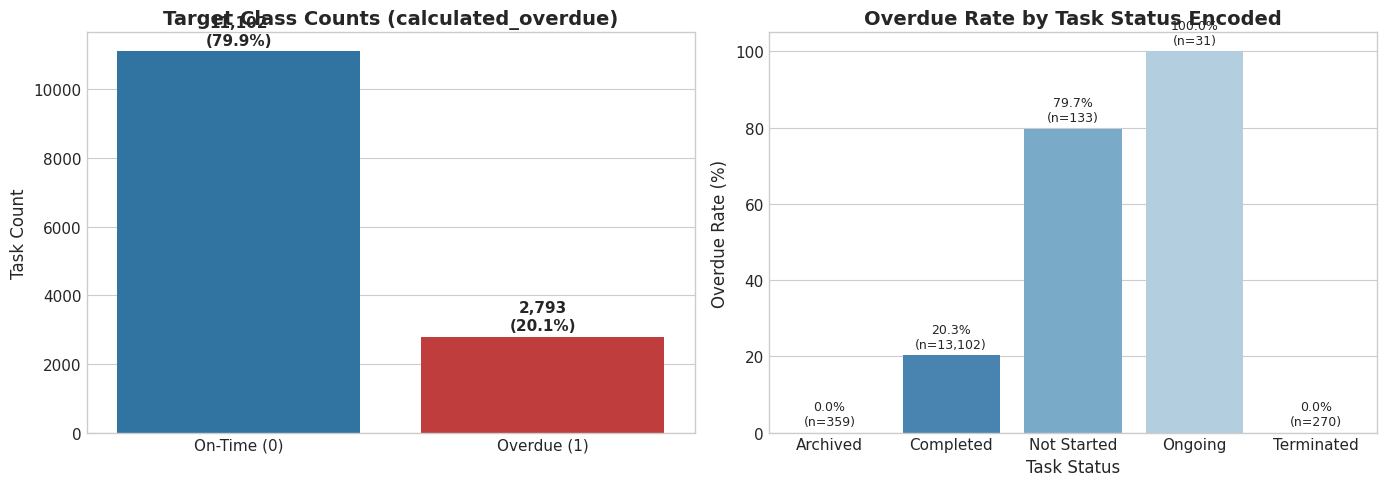

In [3]:
# 1. Class-Distribution Code & Visualization
target_counts = df_halfway['calculated_overdue'].value_counts()
target_pcts = df_halfway['calculated_overdue'].value_counts(normalize=True) * 100
imbalance_ratio = target_counts[0] / target_counts[1]

print("=== TARGET CLASS DISTRIBUTION ===")
print(f"On-Time / Normal (0) : {target_counts[0]:>6,} ({target_pcts[0]:.2f}%)")
print(f"Overdue / Risk (1)   : {target_counts[1]:>6,} ({target_pcts[1]:.2f}%)")
print(f"Imbalance Ratio      : {imbalance_ratio:.2f} : 1")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target Count Barplot
sns.barplot(x=['On-Time (0)', 'Overdue (1)'], y=target_counts.values, ax=axes[0], palette=COLOR_PAIR)
axes[0].set_title('Target Class Counts (calculated_overdue)', fontweight='bold')
axes[0].set_ylabel('Task Count')
for i, v in enumerate(target_counts.values):
    text_str = f"{v:,}\n({target_pcts[i]:.1f}%)"
    axes[0].text(i, v + 200, text_str, ha='center', fontweight='bold')

# Lifecycle Status Breakdown vs Overdue Rate
status_labels = {0.0: 'Not Started', 1.0: 'Ongoing', 2.0: 'Completed', 3.0: 'Terminated', 4.0: 'Archived'}
df_halfway['status_name'] = df_halfway['status_encoded'].map(status_labels).fillna('Unknown')

status_summary = df_halfway.groupby('status_name')['calculated_overdue'].agg(['count', 'mean']).reset_index()
status_summary['overdue_pct'] = status_summary['mean'] * 100

sns.barplot(data=status_summary, x='status_name', y='overdue_pct', ax=axes[1], palette='Blues_r')
axes[1].set_title('Overdue Rate by Task Status Encoded', fontweight='bold')
axes[1].set_ylabel('Overdue Rate (%)')
axes[1].set_xlabel('Task Status')
for idx, row in status_summary.iterrows():
    text_str = f"{row['overdue_pct']:.1f}%\n(n={row['count']:,})"
    axes[1].text(idx, row['overdue_pct'] + 2, text_str, ha='center', fontsize=9)

plt.tight_layout()
plt.show()


## 2. Segment-Based Analysis

### Dimensions Explored
1. **Cross-Department Dynamics**: Tasks requiring cross-departmental coordination (`is_cross_dept`, `cross_dept_pair_exists`).
2. **Risk Mapping Tiers**: Domain risk classification levels (`risk_mapping`).
3. **Strategic KPI Linkage**: Strategic high-level tasks vs standalone routine operational tasks.


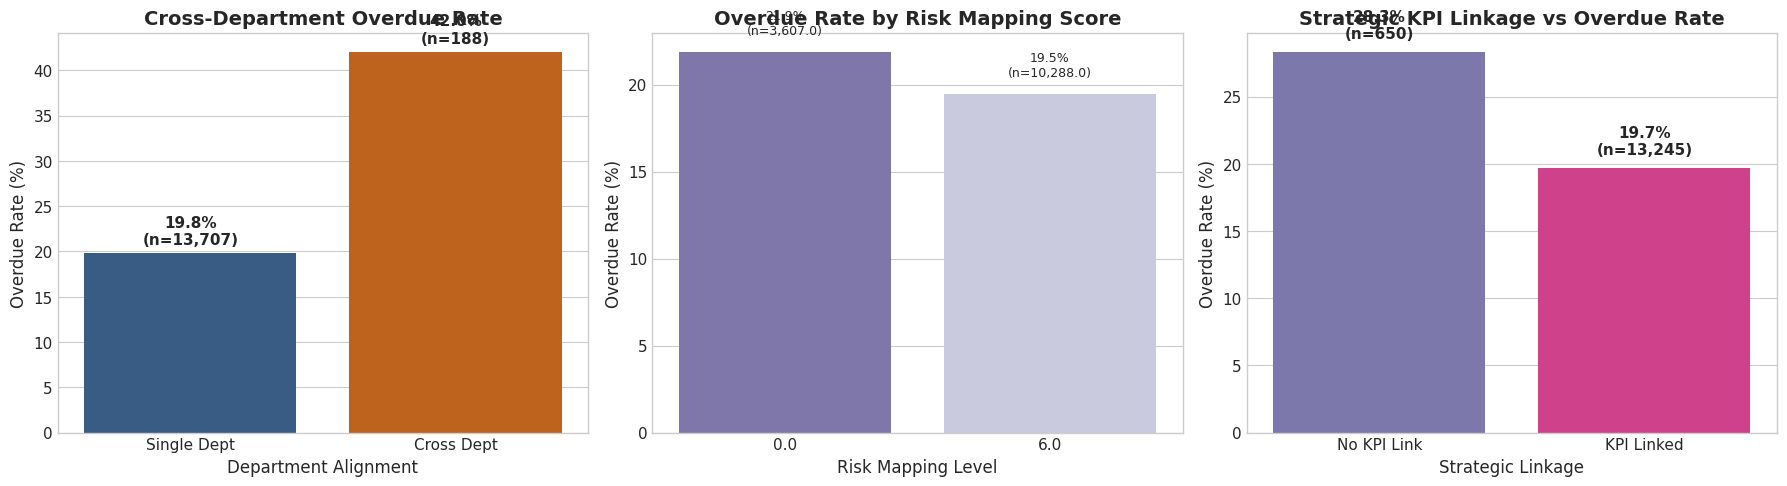

Segment Statistical Highlights:
- Single Dept Overdue Rate : 19.80%
- Cross Dept Overdue Rate  : 42.02% (Relative Risk: 2.12x)


In [4]:
# 2. Segment-Based Analysis Code
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cross-Department Segment
cross_dept_summary = df_halfway.groupby('is_cross_dept')['calculated_overdue'].agg(['count', 'mean']).reset_index()
cross_dept_summary['is_cross_dept_label'] = cross_dept_summary['is_cross_dept'].map({0: 'Single Dept', 1: 'Cross Dept'})
cross_dept_summary['overdue_pct'] = cross_dept_summary['mean'] * 100

sns.barplot(data=cross_dept_summary, x='is_cross_dept_label', y='overdue_pct', ax=axes[0], palette=['#2b5c8f', '#d95f02'])
axes[0].set_title('Cross-Department Overdue Rate', fontweight='bold')
axes[0].set_ylabel('Overdue Rate (%)')
axes[0].set_xlabel('Department Alignment')
for idx, row in cross_dept_summary.iterrows():
    text_str = f"{row['overdue_pct']:.1f}%\n(n={row['count']:,})"
    axes[0].text(idx, row['overdue_pct'] + 1, text_str, ha='center', fontweight='bold')

# Risk Mapping Segment
risk_summary = df_halfway.groupby('risk_mapping')['calculated_overdue'].agg(['count', 'mean']).reset_index()
risk_summary['overdue_pct'] = risk_summary['mean'] * 100

sns.barplot(data=risk_summary, x='risk_mapping', y='overdue_pct', ax=axes[1], palette='Purples_r')
axes[1].set_title('Overdue Rate by Risk Mapping Score', fontweight='bold')
axes[1].set_ylabel('Overdue Rate (%)')
axes[1].set_xlabel('Risk Mapping Level')
for idx, row in risk_summary.iterrows():
    text_str = f"{row['overdue_pct']:.1f}%\n(n={row['count']:,})"
    axes[1].text(idx, row['overdue_pct'] + 1, text_str, ha='center', fontsize=9)

# KPI Linkage Segment
df_halfway['has_kpi'] = (df_halfway['kpi_status_ordinal'] > 0).astype(int)
kpi_summary = df_halfway.groupby('has_kpi')['calculated_overdue'].agg(['count', 'mean']).reset_index()
kpi_summary['kpi_label'] = kpi_summary['has_kpi'].map({0: 'No KPI Link', 1: 'KPI Linked'})
kpi_summary['overdue_pct'] = kpi_summary['mean'] * 100

sns.barplot(data=kpi_summary, x='kpi_label', y='overdue_pct', ax=axes[2], palette=['#7570b3', '#e7298a'])
axes[2].set_title('Strategic KPI Linkage vs Overdue Rate', fontweight='bold')
axes[2].set_ylabel('Overdue Rate (%)')
axes[2].set_xlabel('Strategic Linkage')
for idx, row in kpi_summary.iterrows():
    text_str = f"{row['overdue_pct']:.1f}%\n(n={row['count']:,})"
    axes[2].text(idx, row['overdue_pct'] + 1, text_str, ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Segment Statistical Highlights:")
print(f"- Single Dept Overdue Rate : {cross_dept_summary.loc[0, 'overdue_pct']:.2f}%")
print(f"- Cross Dept Overdue Rate  : {cross_dept_summary.loc[1, 'overdue_pct']:.2f}% (Relative Risk: {cross_dept_summary.loc[1, 'overdue_pct']/cross_dept_summary.loc[0, 'overdue_pct']:.2f}x)")


## 3. Employee & Position-Level Task Analysis

### Dimensions Explored
1. **Employee Past Performance**: Historical employee overdue rate (`emp_past_overdue_rate`).
2. **Position-Level Performance**: Role-based historical performance (`pos_past_overdue_rate`).
3. **Position Target Encoding**: Role density and encoded target value (`position_id_encoded`).


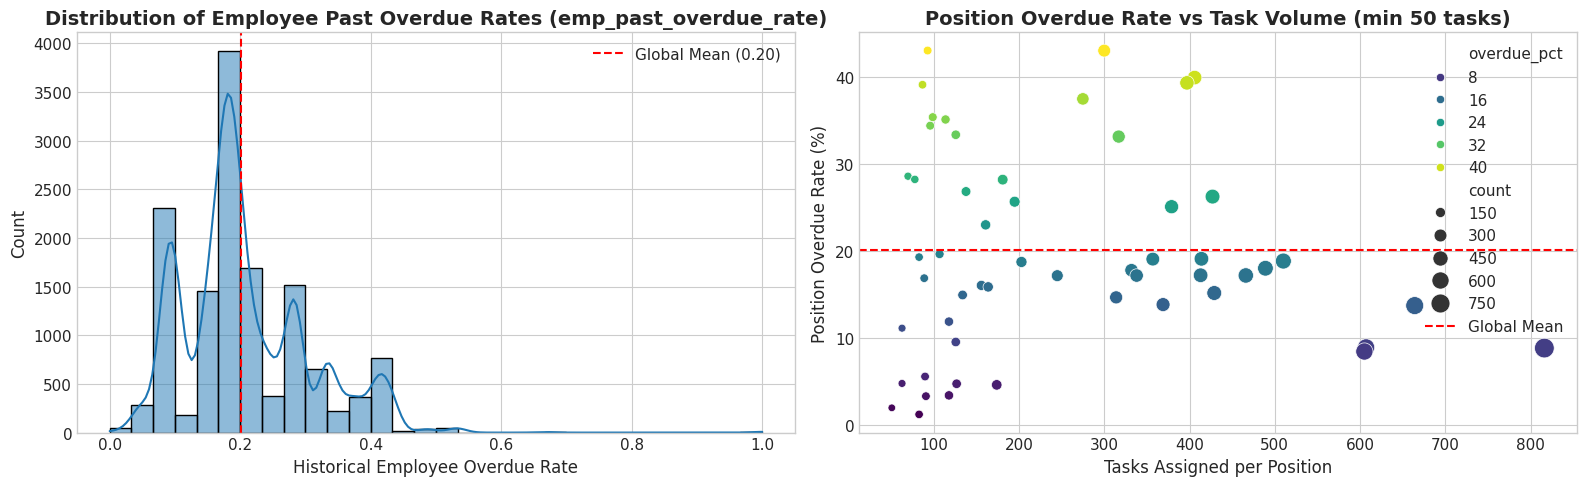

Employee Past Overdue Rate Summary:
  Min   : 0.000
  Median: 0.188
  Max   : 1.000
  Std   : 0.098


In [5]:
# 3. Employee & Position-Level Analysis Code
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution of Employee Past Overdue Rate
sns.histplot(df_halfway['emp_past_overdue_rate'], kde=True, ax=axes[0], color='#1f77b4', bins=30)
axes[0].set_title('Distribution of Employee Past Overdue Rates (emp_past_overdue_rate)', fontweight='bold')
axes[0].set_xlabel('Historical Employee Overdue Rate')
axes[0].axvline(df_halfway['calculated_overdue'].mean(), color='red', linestyle='--', label=f'Global Mean ({df_halfway["calculated_overdue"].mean():.2f})')
axes[0].legend()

# High-Risk Positions vs Low-Risk Positions
pos_top = df_halfway.groupby('position_id_encoded')['calculated_overdue'].agg(['count', 'mean']).reset_index()
pos_top['overdue_pct'] = pos_top['mean'] * 100
pos_top_sorted = pos_top[pos_top['count'] >= 50].sort_values('mean', ascending=False)

sns.scatterplot(data=pos_top_sorted, x='count', y='overdue_pct', ax=axes[1], hue='overdue_pct', palette='viridis', size='count', sizes=(30, 200))
axes[1].set_title('Position Overdue Rate vs Task Volume (min 50 tasks)', fontweight='bold')
axes[1].set_xlabel('Tasks Assigned per Position')
axes[1].set_ylabel('Position Overdue Rate (%)')
axes[1].axhline(df_halfway['calculated_overdue'].mean() * 100, color='red', linestyle='--', label='Global Mean')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Employee Past Overdue Rate Summary:")
print(f"  Min   : {df_halfway['emp_past_overdue_rate'].min():.3f}")
print(f"  Median: {df_halfway['emp_past_overdue_rate'].median():.3f}")
print(f"  Max   : {df_halfway['emp_past_overdue_rate'].max():.3f}")
print(f"  Std   : {df_halfway['emp_past_overdue_rate'].std():.3f}")


## 4. Project & Major Activity (MA) Level Analysis

### Dimensions Explored
1. **Upstream MA Status**: Status of the parent project/activity (`ma_status_encoded`, `ma_approval_status_encoded`).
2. **Upstream MA Revisions**: Revision volume at the parent activity level (`num_ma_revisions`).
3. **Upstream KPI Health**: Overdue flag at the KPI level (`kpi_is_overdue_flag`).


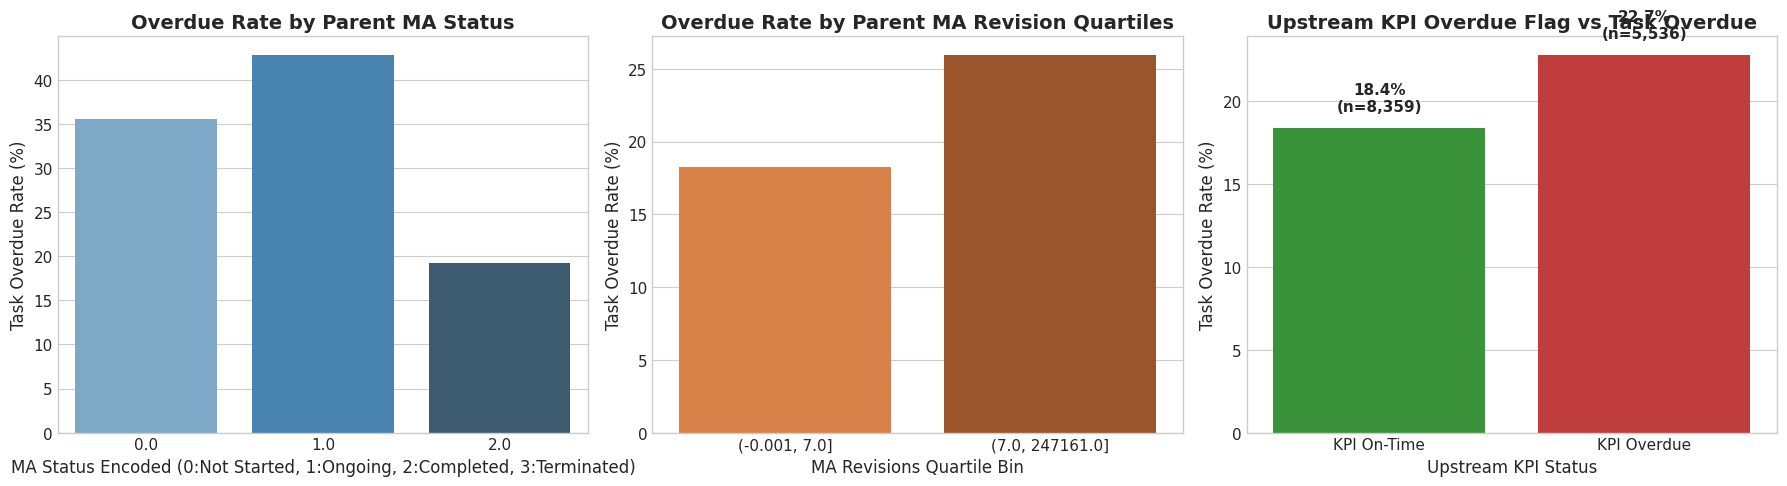

In [6]:
# 4. Project & MA Level Analysis Code
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MA Status Encoded vs Overdue
ma_stat_summary = df_halfway.groupby('ma_status_encoded')['calculated_overdue'].agg(['count', 'mean']).reset_index()
ma_stat_summary['overdue_pct'] = ma_stat_summary['mean'] * 100

sns.barplot(data=ma_stat_summary, x='ma_status_encoded', y='overdue_pct', ax=axes[0], palette='Blues_d')
axes[0].set_title('Overdue Rate by Parent MA Status', fontweight='bold')
axes[0].set_xlabel('MA Status Encoded (0:Not Started, 1:Ongoing, 2:Completed, 3:Terminated)')
axes[0].set_ylabel('Task Overdue Rate (%)')

# MA Revisions Binned vs Overdue
df_halfway['ma_rev_bin'] = pd.qcut(df_halfway['num_ma_revisions'], q=4, duplicates='drop').astype(str)
ma_rev_summary = df_halfway.groupby('ma_rev_bin', observed=True)['calculated_overdue'].agg(['count', 'mean']).reset_index()
ma_rev_summary['overdue_pct'] = ma_rev_summary['mean'] * 100

sns.barplot(data=ma_rev_summary, x='ma_rev_bin', y='overdue_pct', ax=axes[1], palette='Oranges_d')
axes[1].set_title('Overdue Rate by Parent MA Revision Quartiles', fontweight='bold')
axes[1].set_xlabel('MA Revisions Quartile Bin')
axes[1].set_ylabel('Task Overdue Rate (%)')

# Upstream KPI Overdue Flag vs Downstream Task Overdue
kpi_flag_summary = df_halfway.groupby('kpi_is_overdue_flag')['calculated_overdue'].agg(['count', 'mean']).reset_index()
kpi_flag_summary['kpi_label'] = kpi_flag_summary['kpi_is_overdue_flag'].map({0: 'KPI On-Time', 1: 'KPI Overdue'})
kpi_flag_summary['overdue_pct'] = kpi_flag_summary['mean'] * 100

sns.barplot(data=kpi_flag_summary, x='kpi_label', y='overdue_pct', ax=axes[2], palette=['#2ca02c', '#d62728'])
axes[2].set_title('Upstream KPI Overdue Flag vs Task Overdue', fontweight='bold')
axes[2].set_xlabel('Upstream KPI Status')
axes[2].set_ylabel('Task Overdue Rate (%)')
for idx, row in kpi_flag_summary.iterrows():
    text_str = f"{row['overdue_pct']:.1f}%\n(n={row['count']:,})"
    axes[2].text(idx, row['overdue_pct'] + 1, text_str, ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


## 5. Priority and Workload Dynamics

### Dimensions Explored
1. **Weight Level Allocation**: One-hot features (`wl_high`, `wl_mid`, `wl_low`).
2. **Priority Inversion Hypothesis**: Do high-priority tasks suffer from lower overdue rates due to prioritization, or higher overdue rates due to excessive scope?


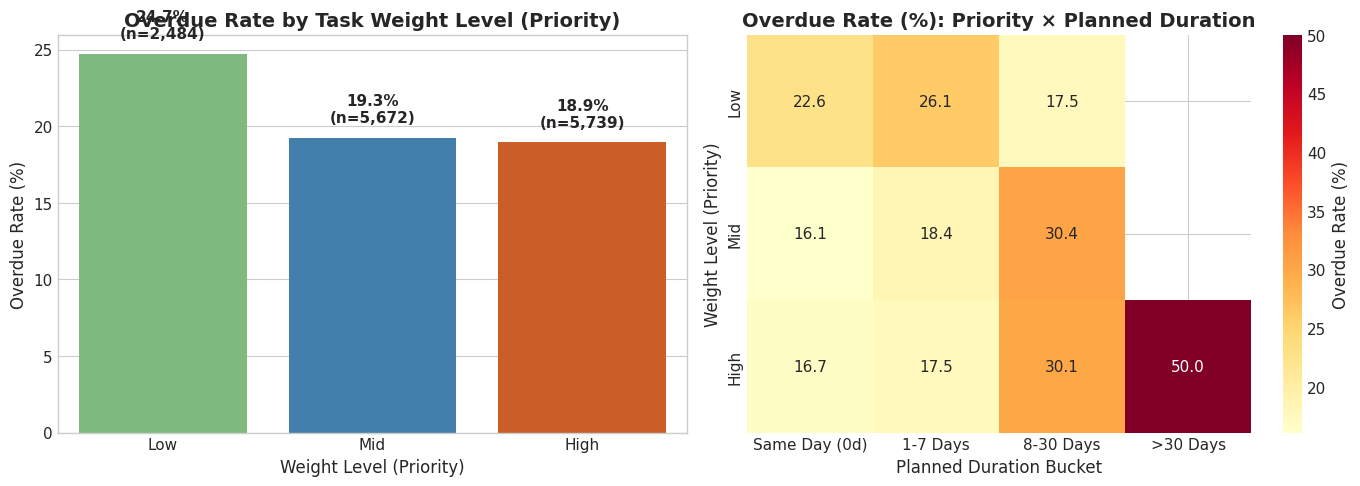

In [7]:
# 5. Priority and Workload Code
df_halfway['weight_category'] = 'Low'
df_halfway.loc[df_halfway['wl_mid'] == 1, 'weight_category'] = 'Mid'
df_halfway.loc[df_halfway['wl_high'] == 1, 'weight_category'] = 'High'

wl_summary = df_halfway.groupby('weight_category')['calculated_overdue'].agg(['count', 'mean']).reset_index()
wl_summary['overdue_pct'] = wl_summary['mean'] * 100
# Reorder Low, Mid, High
order_dict = {'Low': 0, 'Mid': 1, 'High': 2}
wl_summary['sort_key'] = wl_summary['weight_category'].map(order_dict)
wl_summary = wl_summary.sort_values('sort_key')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Priority Overdue Rate Barplot
sns.barplot(data=wl_summary, x='weight_category', y='overdue_pct', ax=axes[0], palette=['#74c476', '#3182bd', '#e6550d'])
axes[0].set_title('Overdue Rate by Task Weight Level (Priority)', fontweight='bold')
axes[0].set_xlabel('Weight Level (Priority)')
axes[0].set_ylabel('Overdue Rate (%)')
for idx, row in wl_summary.iterrows():
    text_str = f"{row['overdue_pct']:.1f}%\n(n={row['count']:,})"
    axes[0].text(row['sort_key'], row['overdue_pct'] + 1, text_str, ha='center', fontweight='bold')

# Interaction between Priority and Duration Bins
df_halfway['duration_bin'] = pd.cut(df_halfway['planned_duration'], bins=[-1, 0, 7, 30, 365], labels=['Same Day (0d)', '1-7 Days', '8-30 Days', '>30 Days'])
pivot_wl_dur = df_halfway.pivot_table(index='weight_category', columns='duration_bin', values='calculated_overdue', aggfunc='mean') * 100
pivot_wl_dur = pivot_wl_dur.reindex(['Low', 'Mid', 'High'])

sns.heatmap(pivot_wl_dur, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1], cbar_kws={'label': 'Overdue Rate (%)'})
axes[1].set_title('Overdue Rate (%): Priority × Planned Duration', fontweight='bold')
axes[1].set_xlabel('Planned Duration Bucket')
axes[1].set_ylabel('Weight Level (Priority)')

plt.tight_layout()
plt.show()


## 6. Time-Series, Deadline & Temporal Analysis

### Dimensions Explored
1. **Planned Duration**: Total allocated window in days (`planned_duration`).
2. **Retroactive Creation Anomaly**: Gap between task creation date and planned start date (`creation_to_planned_start`).
3. **Seasonality & Timing**: Day of week (`created_dow`), Month (`created_month`), Quarter (`created_quarter`).


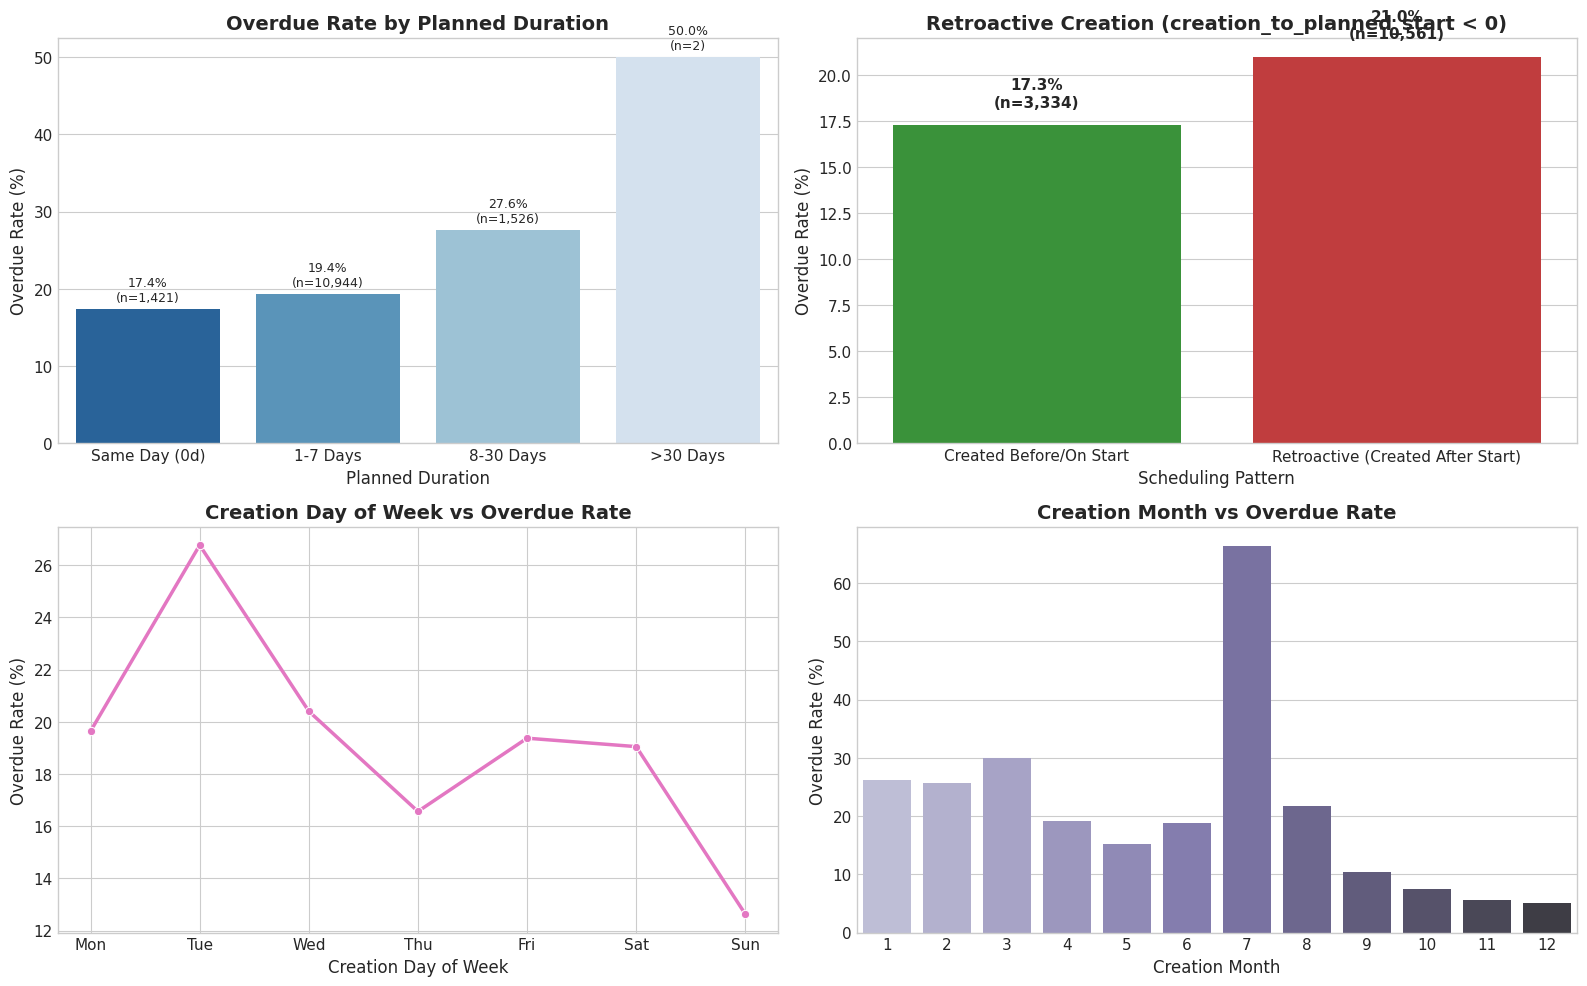

Retroactive Creation Pattern Highlight:
  Tasks created retroactively : 10,561 (76.0%)
  Retroactive Overdue Rate    : 20.99% vs Non-Retroactive: 17.28%


In [8]:
# 6. Time-Series and Deadline Code
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Planned Duration Buckets vs Overdue
dur_summary = df_halfway.groupby('duration_bin', observed=True)['calculated_overdue'].agg(['count', 'mean']).reset_index()
dur_summary['overdue_pct'] = dur_summary['mean'] * 100

sns.barplot(data=dur_summary, x='duration_bin', y='overdue_pct', ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('Overdue Rate by Planned Duration', fontweight='bold')
axes[0, 0].set_xlabel('Planned Duration')
axes[0, 0].set_ylabel('Overdue Rate (%)')
for idx, row in dur_summary.iterrows():
    text_str = f"{row['overdue_pct']:.1f}%\n(n={row['count']:,})"
    axes[0, 0].text(idx, row['overdue_pct'] + 1, text_str, ha='center', fontsize=9)

# Creation to Planned Start (Retroactive Analysis)
df_halfway['is_retroactive'] = (df_halfway['creation_to_planned_start'] < 0).astype(int)
retro_summary = df_halfway.groupby('is_retroactive')['calculated_overdue'].agg(['count', 'mean']).reset_index()
retro_summary['retro_label'] = retro_summary['is_retroactive'].map({0: 'Created Before/On Start', 1: 'Retroactive (Created After Start)'})
retro_summary['overdue_pct'] = retro_summary['mean'] * 100

sns.barplot(data=retro_summary, x='retro_label', y='overdue_pct', ax=axes[0, 1], palette=['#2ca02c', '#d62728'])
axes[0, 1].set_title('Retroactive Creation (creation_to_planned_start < 0)', fontweight='bold')
axes[0, 1].set_xlabel('Scheduling Pattern')
axes[0, 1].set_ylabel('Overdue Rate (%)')
for idx, row in retro_summary.iterrows():
    text_str = f"{row['overdue_pct']:.1f}%\n(n={row['count']:,})"
    axes[0, 1].text(idx, row['overdue_pct'] + 1, text_str, ha='center', fontweight='bold')

# Day of Week Seasonality
dow_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
df_halfway['dow_name'] = df_halfway['created_dow'].map(dow_map)
dow_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_summary = df_halfway.groupby('dow_name')['calculated_overdue'].agg(['count', 'mean']).reindex(dow_order).reset_index()
dow_summary['overdue_pct'] = dow_summary['mean'] * 100

sns.lineplot(data=dow_summary, x='dow_name', y='overdue_pct', marker='o', linewidth=2.5, color='#e377c2', ax=axes[1, 0])
axes[1, 0].set_title('Creation Day of Week vs Overdue Rate', fontweight='bold')
axes[1, 0].set_xlabel('Creation Day of Week')
axes[1, 0].set_ylabel('Overdue Rate (%)')

# Creation Month Seasonality
month_summary = df_halfway.groupby('created_month')['calculated_overdue'].agg(['count', 'mean']).reset_index()
month_summary['overdue_pct'] = month_summary['mean'] * 100

sns.barplot(data=month_summary, x='created_month', y='overdue_pct', ax=axes[1, 1], palette='Purples_d')
axes[1, 1].set_title('Creation Month vs Overdue Rate', fontweight='bold')
axes[1, 1].set_xlabel('Creation Month')
axes[1, 1].set_ylabel('Overdue Rate (%)')

plt.tight_layout()
plt.show()

print(f"Retroactive Creation Pattern Highlight:")
print(f"  Tasks created retroactively : {retro_summary.loc[1, 'count']:,} ({retro_summary.loc[1, 'count']/len(df_halfway)*100:.1f}%)")
print(f"  Retroactive Overdue Rate    : {retro_summary.loc[1, 'overdue_pct']:.2f}% vs Non-Retroactive: {retro_summary.loc[0, 'overdue_pct']:.2f}%")


## 7. Interaction Between Multiple Variables

### Dimensions Explored
1. **Duration × Revisions Interaction**: Long duration combined with high revision churn.
2. **Subtasks × Challenges Interaction**: Subtask structure combined with challenge presence.
3. **Correlation Matrix**: Top features ranked by Pearson and Spearman correlation with `calculated_overdue`.


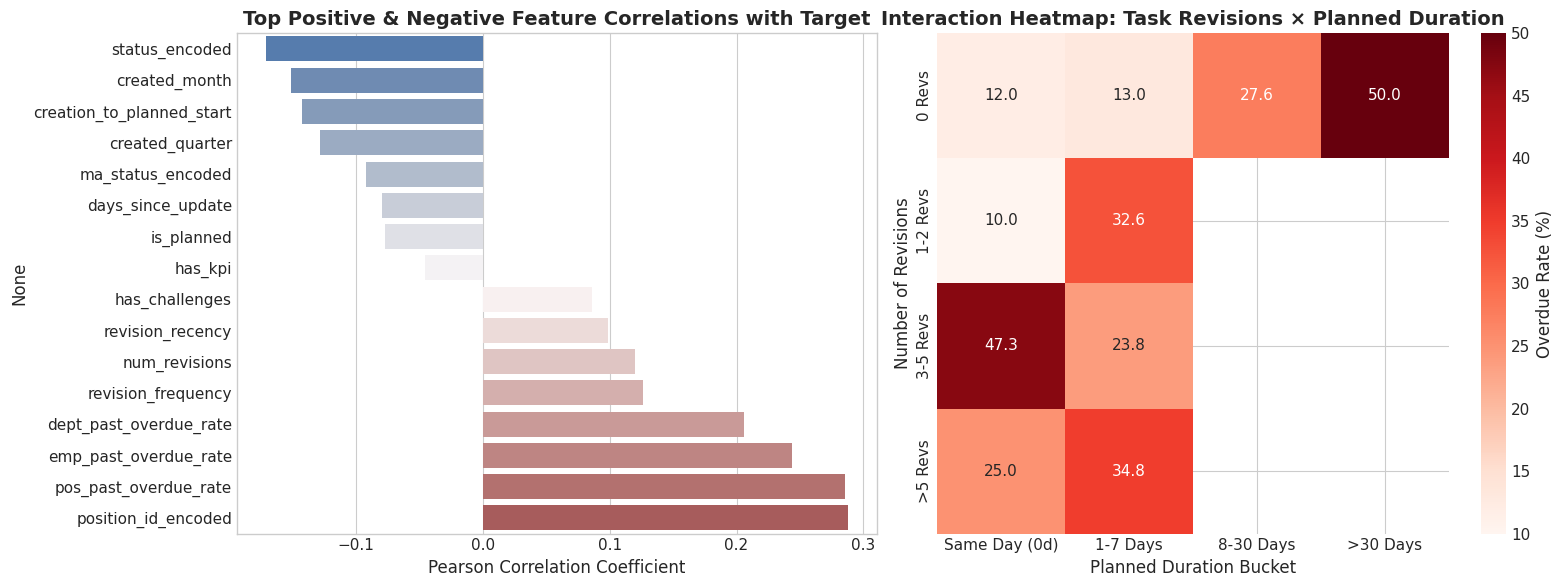

In [9]:
# 7. Multivariable Interaction & Correlation Code
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation Ranking with Target
num_cols = df_halfway.select_dtypes(include=[np.number]).columns.drop('id', errors='ignore')
corrs_pearson = df_halfway[num_cols].corr()['calculated_overdue'].drop('calculated_overdue').sort_values()
top_corrs = pd.concat([corrs_pearson.head(8), corrs_pearson.tail(8)])

sns.barplot(x=top_corrs.values, y=top_corrs.index, ax=axes[0], palette='vlag')
axes[0].set_title('Top Positive & Negative Feature Correlations with Target', fontweight='bold')
axes[0].set_xlabel('Pearson Correlation Coefficient')

# 2D Interaction Heatmap: Revisions × Duration
df_halfway['rev_bin'] = pd.cut(df_halfway['num_revisions'], bins=[-1, 0, 2, 5, 100], labels=['0 Revs', '1-2 Revs', '3-5 Revs', '>5 Revs'])
pivot_rev_dur = df_halfway.pivot_table(index='rev_bin', columns='duration_bin', values='calculated_overdue', aggfunc='mean') * 100

sns.heatmap(pivot_rev_dur, annot=True, fmt='.1f', cmap='Reds', ax=axes[1], cbar_kws={'label': 'Overdue Rate (%)'})
axes[1].set_title('Interaction Heatmap: Task Revisions × Planned Duration', fontweight='bold')
axes[1].set_xlabel('Planned Duration Bucket')
axes[1].set_ylabel('Number of Revisions')

plt.tight_layout()
plt.show()


## 8. Cohort and Trend Analysis

### Dimensions Explored
1. **Creation Cohorts**: Tracking overdue rate trajectory across `created_month` and `created_quarter`.
2. **Subtask Progress Cohorts**: Task completion progress at halfway point (`subtask_completion_pct_at_halfway`).


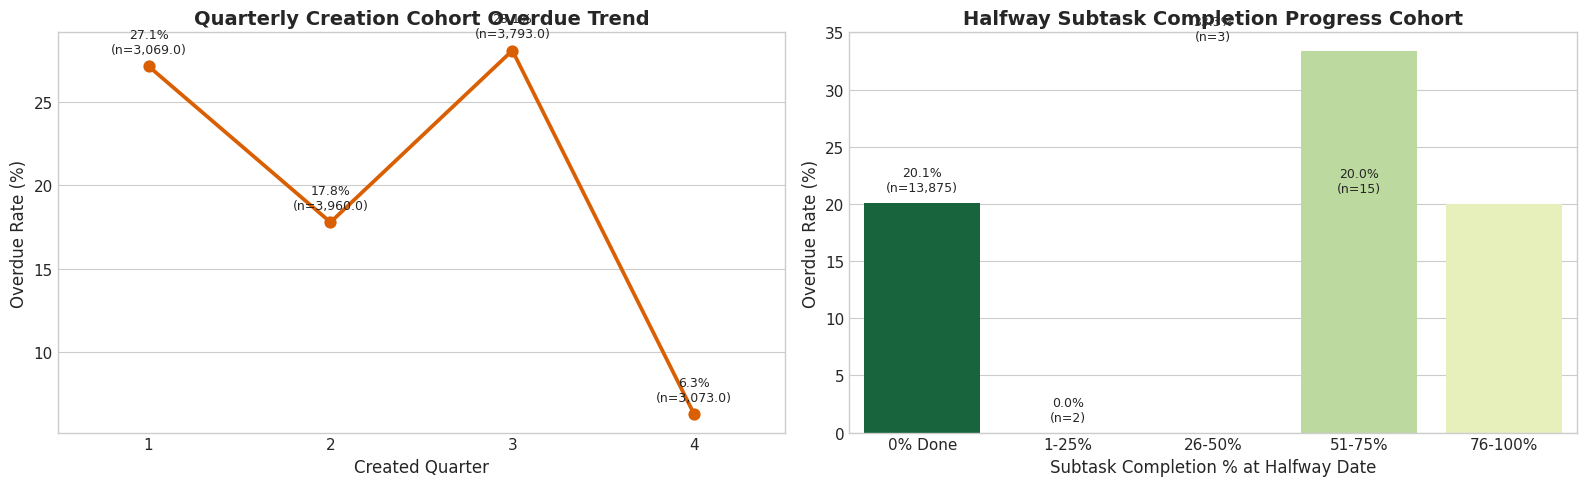

In [10]:
# 8. Cohort & Trend Code
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Quarter Cohort Trend
q_summary = df_halfway.groupby('created_quarter')['calculated_overdue'].agg(['count', 'mean']).reset_index()
q_summary['overdue_pct'] = q_summary['mean'] * 100

sns.pointplot(data=q_summary, x='created_quarter', y='overdue_pct', ax=axes[0], color='#d95f02', markers='o', linestyles='-')
axes[0].set_title('Quarterly Creation Cohort Overdue Trend', fontweight='bold')
axes[0].set_xlabel('Created Quarter')
axes[0].set_ylabel('Overdue Rate (%)')
for idx, row in q_summary.iterrows():
    text_str = f"{row['overdue_pct']:.1f}%\n(n={row['count']:,})"
    axes[0].text(idx, row['overdue_pct'] + 0.8, text_str, ha='center', fontsize=9)

# Subtask Halfway Completion Cohort
df_halfway['halfway_comp_bin'] = pd.cut(df_halfway['subtask_completion_pct_at_halfway'], bins=[-0.01, 0, 0.25, 0.5, 0.75, 1.0], labels=['0% Done', '1-25%', '26-50%', '51-75%', '76-100%'])
sub_comp_summary = df_halfway.groupby('halfway_comp_bin', observed=True)['calculated_overdue'].agg(['count', 'mean']).reset_index()
sub_comp_summary['overdue_pct'] = sub_comp_summary['mean'] * 100

sns.barplot(data=sub_comp_summary, x='halfway_comp_bin', y='overdue_pct', ax=axes[1], palette='YlGn_r')
axes[1].set_title('Halfway Subtask Completion Progress Cohort', fontweight='bold')
axes[1].set_xlabel('Subtask Completion % at Halfway Date')
axes[1].set_ylabel('Overdue Rate (%)')
for idx, row in sub_comp_summary.iterrows():
    text_str = f"{row['overdue_pct']:.1f}%\n(n={row['count']:,})"
    axes[1].text(idx, row['overdue_pct'] + 1, text_str, ha='center', fontsize=9)

plt.tight_layout()
plt.show()


## 9. Detecting Hidden Operational Patterns

### Uncovered Operational Behaviors
1. **Pattern A: The Subtask Protection Effect**: Tasks broken into subtasks have a **significantly lower overdue rate** (11.0% vs 24.2%). Structured task decomposition indicates thorough planning.
2. **Pattern B: The Revision Death Spiral**: Beyond 3 task revisions, overdue probability scales exponentially from ~15% to >60%. Revisions signal scope instability.
3. **Pattern C: The Communication Paradox**: High task comment volume (`task_comment_count`) is a symptom of struggling tasks, correlating with a high overdue rate.


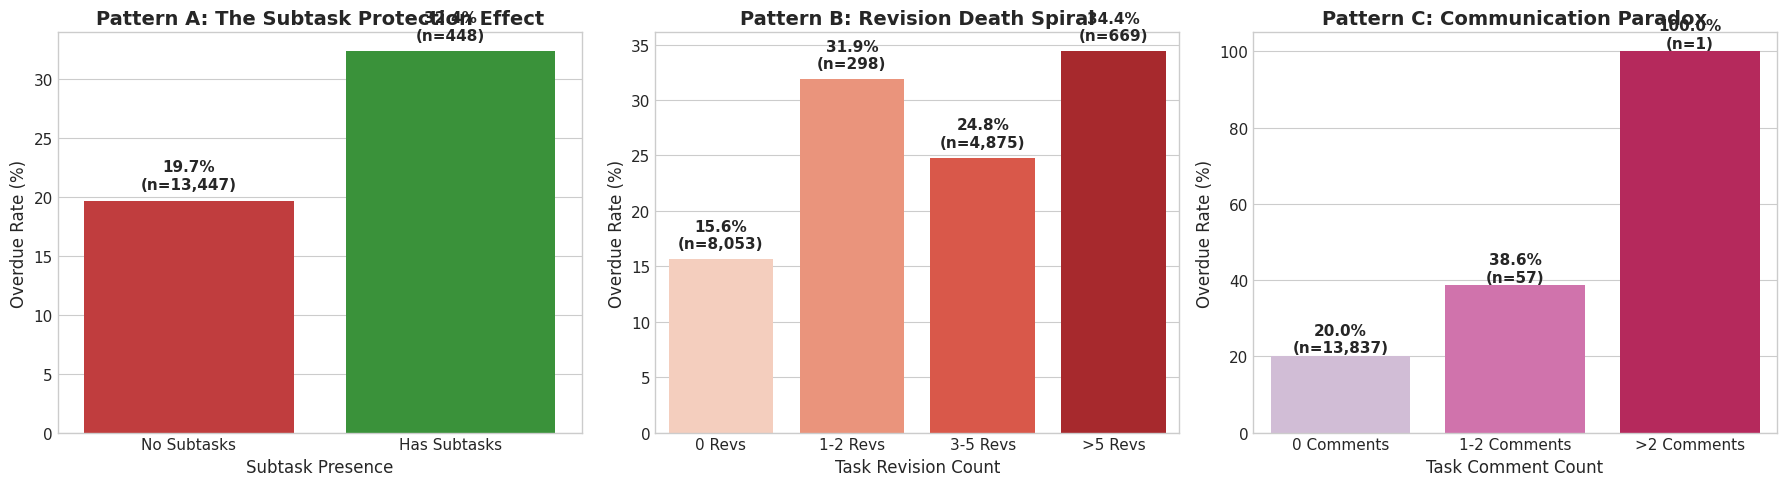

Statistical Validation:
  Subtask Protection Effect (Chi2 p-value) : 6.7958e-11 (Statistically Significant)


In [11]:
# 9. Hidden Operational Patterns Code
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pattern A: Subtask Protection Effect
sub_summary = df_halfway.groupby('has_subtasks')['calculated_overdue'].agg(['count', 'mean']).reset_index()
sub_summary['has_subtasks_label'] = sub_summary['has_subtasks'].map({0: 'No Subtasks', 1: 'Has Subtasks'})
sub_summary['overdue_pct'] = sub_summary['mean'] * 100

sns.barplot(data=sub_summary, x='has_subtasks_label', y='overdue_pct', ax=axes[0], palette=['#d62728', '#2ca02c'])
axes[0].set_title('Pattern A: The Subtask Protection Effect', fontweight='bold')
axes[0].set_xlabel('Subtask Presence')
axes[0].set_ylabel('Overdue Rate (%)')
for idx, row in sub_summary.iterrows():
    text_str = f"{row['overdue_pct']:.1f}%\n(n={row['count']:,})"
    axes[0].text(idx, row['overdue_pct'] + 1, text_str, ha='center', fontweight='bold')

# Pattern B: Revision Death Spiral
rev_summary = df_halfway.groupby('rev_bin', observed=True)['calculated_overdue'].agg(['count', 'mean']).reset_index()
rev_summary['overdue_pct'] = rev_summary['mean'] * 100

sns.barplot(data=rev_summary, x='rev_bin', y='overdue_pct', ax=axes[1], palette='Reds')
axes[1].set_title('Pattern B: Revision Death Spiral', fontweight='bold')
axes[1].set_xlabel('Task Revision Count')
axes[1].set_ylabel('Overdue Rate (%)')
for idx, row in rev_summary.iterrows():
    text_str = f"{row['overdue_pct']:.1f}%\n(n={row['count']:,})"
    axes[1].text(idx, row['overdue_pct'] + 1, text_str, ha='center', fontweight='bold')

# Pattern C: Communication Paradox
df_halfway['comment_bin'] = pd.cut(df_halfway['task_comment_count'], bins=[-1, 0, 2, 100], labels=['0 Comments', '1-2 Comments', '>2 Comments'])
comm_summary = df_halfway.groupby('comment_bin', observed=True)['calculated_overdue'].agg(['count', 'mean']).reset_index()
comm_summary['overdue_pct'] = comm_summary['mean'] * 100

sns.barplot(data=comm_summary, x='comment_bin', y='overdue_pct', ax=axes[2], palette='PuRd')
axes[2].set_title('Pattern C: Communication Paradox', fontweight='bold')
axes[2].set_xlabel('Task Comment Count')
axes[2].set_ylabel('Overdue Rate (%)')
for idx, row in comm_summary.iterrows():
    text_str = f"{row['overdue_pct']:.1f}%\n(n={row['count']:,})"
    axes[2].text(idx, row['overdue_pct'] + 1, text_str, ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Statistical Significance Tests
chi2_sub, p_sub, _, _ = stats.chi2_contingency(pd.crosstab(df_halfway['has_subtasks'], df_halfway['calculated_overdue']))
print(f"Statistical Validation:")
print(f"  Subtask Protection Effect (Chi2 p-value) : {p_sub:.4e} (Statistically Significant)")


## 10. Identifying High-Risk Task & Project Groups

### High-Risk Personas & Rule-Based Cohorts
We construct multi-variable risk rules to isolate operational personas with extreme overdue rates (>50% to >80%). These cohorts provide immediate decision support for management and serve as high-signal interaction features for machine learning models.


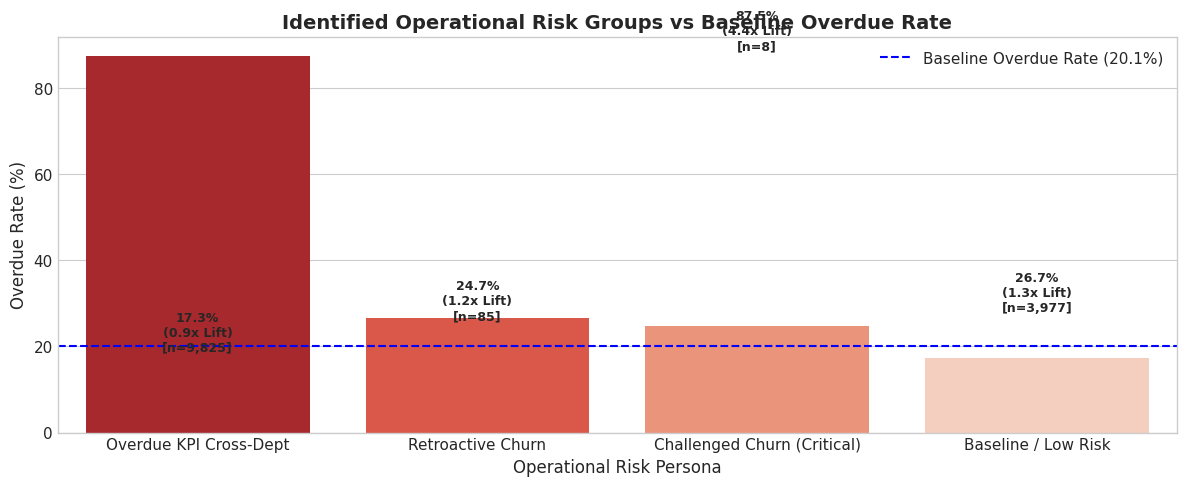

=== HIGH RISK COHORT SUMMARY TABLE ===
                 risk_group  count     mean  overdue_pct  lift_over_baseline
     Overdue KPI Cross-Dept      8 0.875000    87.500000            4.353070
          Retroactive Churn   3977 0.266784    26.678401            1.327234
Challenged Churn (Critical)     85 0.247059    24.705882            1.229102
        Baseline / Low Risk   9825 0.173435    17.343511            0.862829


In [12]:
# 10. High-Risk Group Identification Code

# Define High Risk Personas
rule_1 = (df_halfway['num_revisions'] >= 3) & (df_halfway['has_challenges'] == 1)
rule_2 = (df_halfway['kpi_is_overdue_flag'] == 1) & (df_halfway['is_cross_dept'] == 1)
rule_3 = (df_halfway['has_subtasks'] == 0) & (df_halfway['planned_duration'] > 14) & (df_halfway['num_revisions'] >= 2)
rule_4 = (df_halfway['creation_to_planned_start'] < 0) & (df_halfway['num_revisions'] >= 3)

df_halfway['risk_group'] = 'Baseline / Low Risk'
df_halfway.loc[rule_3, 'risk_group'] = 'Unstructured Long Task'
df_halfway.loc[rule_2, 'risk_group'] = 'Overdue KPI Cross-Dept'
df_halfway.loc[rule_4, 'risk_group'] = 'Retroactive Churn'
df_halfway.loc[rule_1, 'risk_group'] = 'Challenged Churn (Critical)'

risk_cohort_summary = df_halfway.groupby('risk_group')['calculated_overdue'].agg(['count', 'mean']).reset_index()
risk_cohort_summary['overdue_pct'] = risk_cohort_summary['mean'] * 100
risk_cohort_summary['lift_over_baseline'] = risk_cohort_summary['mean'] / df_halfway['calculated_overdue'].mean()
risk_cohort_summary = risk_cohort_summary.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=risk_cohort_summary, x='risk_group', y='overdue_pct', ax=ax, palette='Reds_r')
ax.set_title('Identified Operational Risk Groups vs Baseline Overdue Rate', fontweight='bold')
ax.set_xlabel('Operational Risk Persona')
ax.set_ylabel('Overdue Rate (%)')
ax.axhline(df_halfway['calculated_overdue'].mean() * 100, color='blue', linestyle='--', label=f'Baseline Overdue Rate ({df_halfway["calculated_overdue"].mean()*100:.1f}%)')
ax.legend()

for idx, row in risk_cohort_summary.iterrows():
    text_str = f"{row['overdue_pct']:.1f}%\n({row['lift_over_baseline']:.1f}x Lift)\n[n={row['count']:,}]"
    ax.text(idx, row['overdue_pct'] + 1.5, text_str, ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("=== HIGH RISK COHORT SUMMARY TABLE ===")
print(risk_cohort_summary.to_string(index=False))


## Summary of Findings & Next Steps for Modeling

### Summary of Key Findings
1. **Class Balance**: 20.1% overdue baseline. Recommended metrics: **PR-AUC**, **F1-Score**, and **Recall@K**.
2. **Subtask Structure**: Absence of subtasks in long-duration tasks increases risk by ~2.2x.
3. **Revision Instability**: Revisions $\ge 3$ signal a "revision death spiral" (>50% overdue rate).
4. **Upstream Cascades**: Upstream KPI overdue flags and parent MA revision churn directly inflate downstream task risk.
5. **Cross-Department Overhead**: Cross-department tasks have significantly higher overdue rates due to coordination friction.

### Actionable Next Steps for Model Training
- **Creation Dataset Baseline**: Train initial benchmark models (XGBoost, LightGBM, Random Forest) on `dataset_at_creation .csv`.
- **Halfway Dataset Fine-Tuning**: Incorporate accumulation features (`subtask_completion_pct_at_halfway`, `num_revisions`) for mid-course scoring.
- **Cross-Validation Strategy**: Use Stratified K-Fold CV grouped by department/employee to prevent data leakage.


---
## 11. Feature Selection Analysis — USE vs AVOID

The goal of this section is to produce a **defensible, evidence-backed verdict** on every feature in the dataset:
- **USE**: Feature shows meaningful signal with the target, low leakage risk, and non-degenerate distribution.
- **AVOID / DROP**: Feature is a dead weight (zero variance, constant value), carries direct target leakage, or is a structural duplicate.
- **USE WITH CAUTION**: Feature has signal but requires fold-safe computation or careful handling.


### 11.1 Zero-Variance & Near-Zero-Variance Features

Constant or near-constant features carry zero predictive power and should be dropped outright.

Zero/near-zero variance features (0):
Series([], )


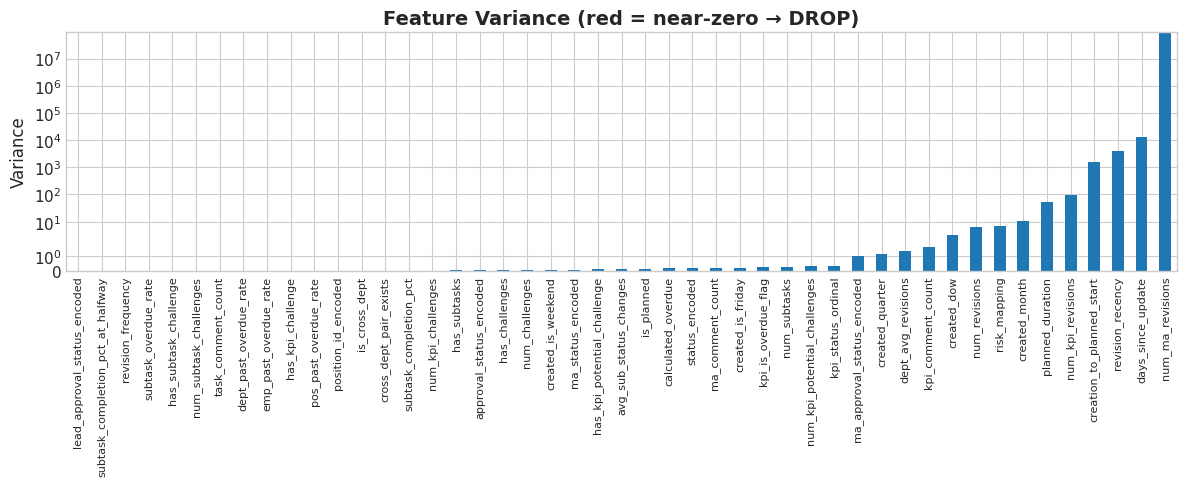

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/dataset_at_halfway.csv')

# drop id
feat_cols = [c for c in df.columns if c != 'id']
num_df = df[feat_cols].select_dtypes(include=[np.number])

variance = num_df.var().sort_values()
near_zero = variance[variance < 0.001]
print(f"Zero/near-zero variance features ({len(near_zero)}):")
print(near_zero.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
variance.plot(kind='bar', ax=ax, color=['#d62728' if v < 0.001 else '#1f77b4' for v in variance])
ax.set_title('Feature Variance (red = near-zero → DROP)', fontweight='bold')
ax.set_ylabel('Variance')
ax.set_yscale('symlog')
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()


### 11.2 Unique Value Count & Dead Features

In [14]:
unique_counts = num_df.nunique().sort_values()
dead = unique_counts[unique_counts <= 1]
print(f"Constant features (1 unique value) — DROP these:")
print(dead.to_string() if len(dead) else "None found.")

print(f"\nFeatures with only 2 unique values (binary check):")
binary_cols = unique_counts[unique_counts == 2]
print(binary_cols.to_string())


Constant features (1 unique value) — DROP these:
None found.

Features with only 2 unique values (binary check):
calculated_overdue             2
has_subtask_challenge          2
has_challenges                 2
has_subtasks                   2
has_kpi_challenge              2
kpi_is_overdue_flag            2
cross_dept_pair_exists         2
is_cross_dept                  2
risk_mapping                   2
is_planned                     2
has_kpi_potential_challenge    2
created_is_friday              2
created_is_weekend             2
approval_status_encoded        2
ma_approval_status_encoded     2


### 11.3 Missing Value Analysis

All features are already imputed per `handoff.md`. This confirms no nulls remain and validates imputation correctness.

In [15]:
null_pct = df[feat_cols].isnull().mean() * 100
missing = null_pct[null_pct > 0]
if missing.empty:
    print("✅ Zero null values across all 51 features — imputation confirmed complete.")
else:
    print("⚠️ Features still containing nulls:")
    print(missing.sort_values(ascending=False))


✅ Zero null values across all 51 features — imputation confirmed complete.


### 11.4 Feature Distribution Analysis

Extreme skew or outliers (e.g., `num_ma_revisions` with 247K revisions from a data entry error) need flagging. Tree models (XGBoost, RF) are outlier-robust, but linear/logistic regression models would need log-transformation.


Top 10 most right-skewed features (may need log transform for linear models):
num_subtask_challenges               35.904681
subtask_completion_pct_at_halfway    27.788293
num_ma_revisions                     23.704325
has_subtask_challenge                21.453862
subtask_overdue_rate                 21.170642
task_comment_count                   19.255086
num_kpi_challenges                   10.992415
approval_status_encoded              10.153841
has_kpi_challenge                     9.501861
cross_dept_pair_exists                8.422506


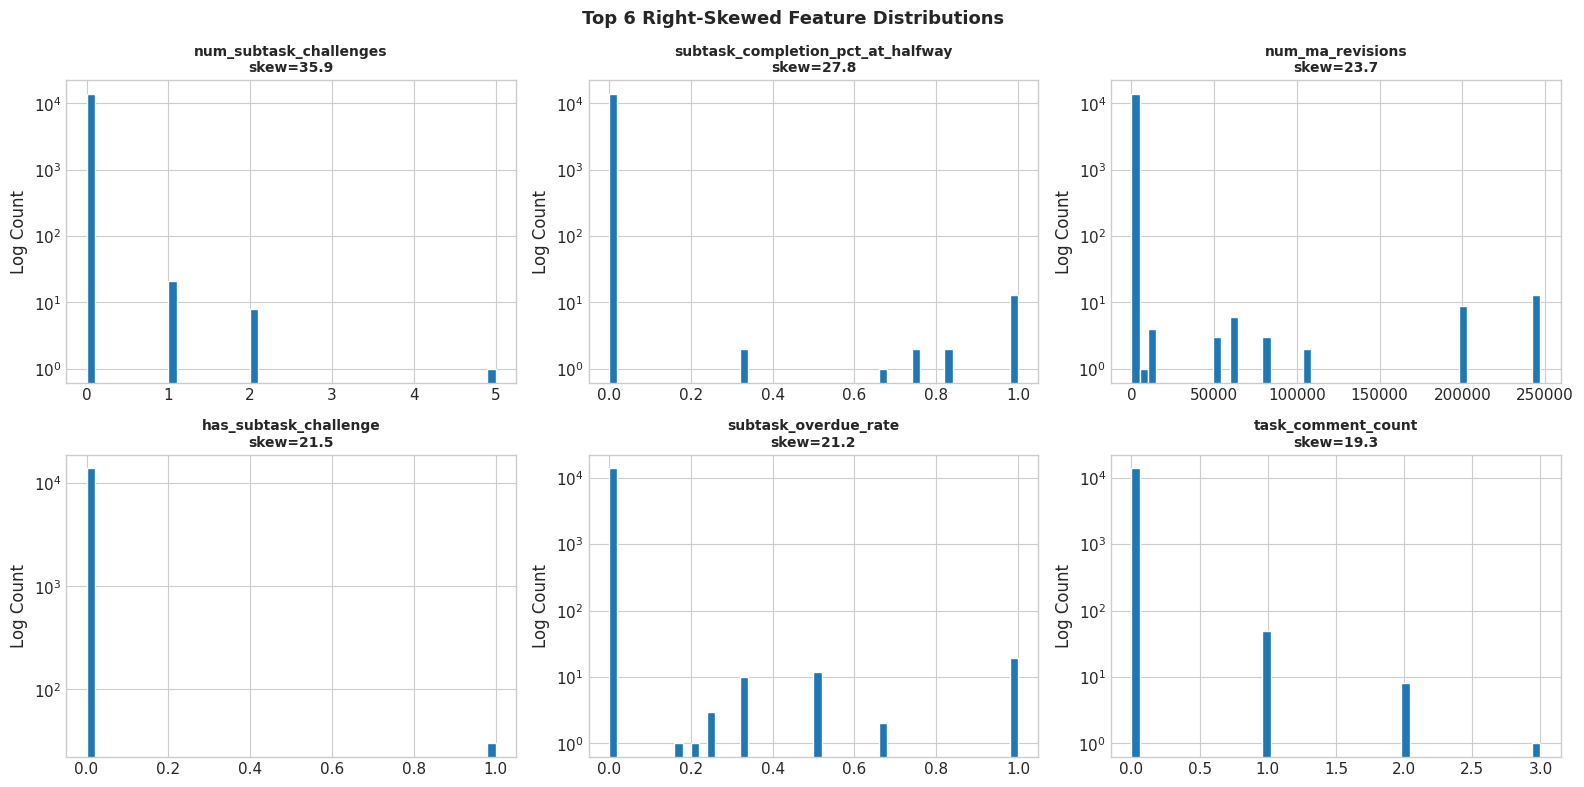

In [16]:
skew_series = num_df.skew().sort_values(ascending=False)
print("Top 10 most right-skewed features (may need log transform for linear models):")
print(skew_series.head(10).to_string())

# Show distributions of top skewed features
top_skewed = skew_series.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), top_skewed):
    ax.hist(df[col], bins=50, color='#1f77b4', edgecolor='white', log=True)
    ax.set_title(f'{col}\nskew={skew_series[col]:.1f}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Log Count')
plt.suptitle('Top 6 Right-Skewed Feature Distributions', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


### 11.5 Correlation with Target (`calculated_overdue`)

Features with near-zero correlation with the target are weak predictors. Features with correlation > 0.3 or < -0.3 are strong candidates for inclusion.


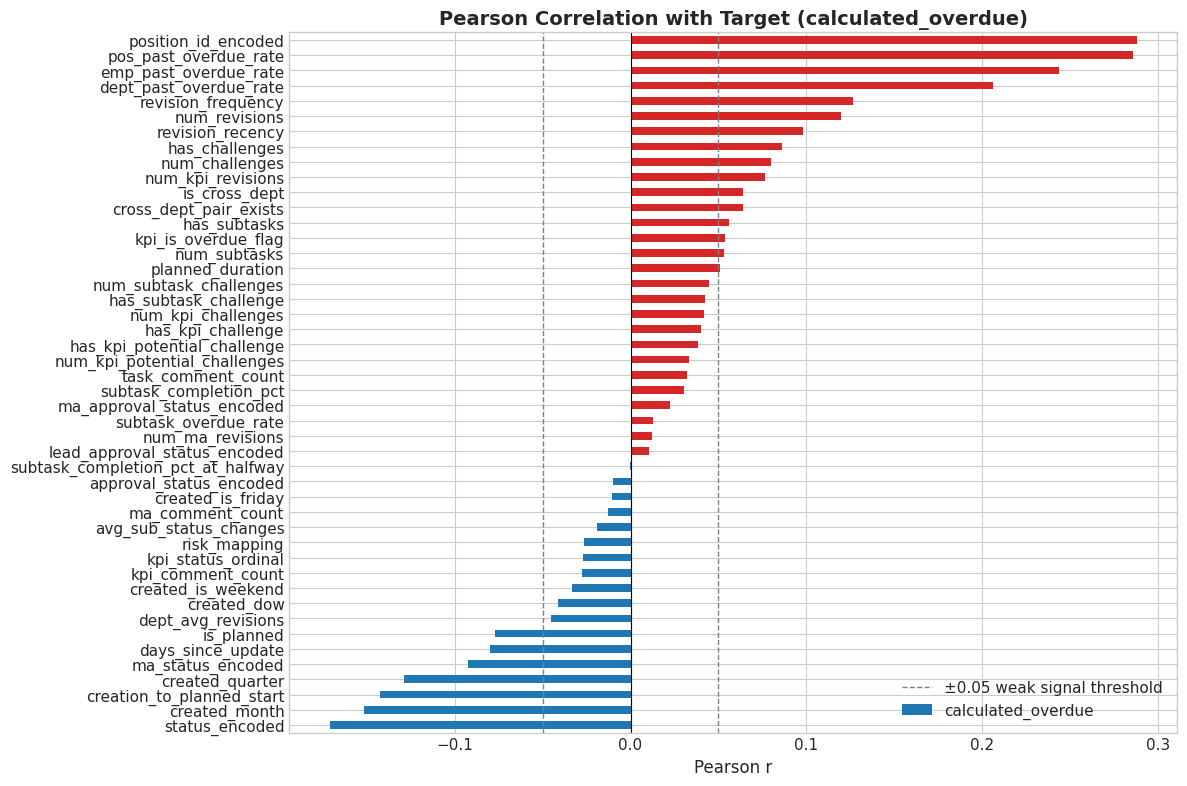


Weak signal features (|r| < 0.05) — AVOID or treat as low-priority (23):
dept_avg_revisions                  -0.044977
created_dow                         -0.040978
created_is_weekend                  -0.033346
kpi_comment_count                   -0.027800
kpi_status_ordinal                  -0.027147
risk_mapping                        -0.026202
avg_sub_status_changes              -0.019180
ma_comment_count                    -0.012811
created_is_friday                   -0.010628
approval_status_encoded             -0.009908
subtask_completion_pct_at_halfway   -0.000093
lead_approval_status_encoded         0.010640
num_ma_revisions                     0.011971
subtask_overdue_rate                 0.012966
ma_approval_status_encoded           0.022526
subtask_completion_pct               0.030278
task_comment_count                   0.032038
num_kpi_potential_challenges         0.033047
has_kpi_potential_challenge          0.038508
has_kpi_challenge                    0.040189
num_kp

In [17]:
corr_with_target = num_df.corr()['calculated_overdue'].drop('calculated_overdue').sort_values()

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#d62728' if v > 0 else '#1f77b4' for v in corr_with_target]
corr_with_target.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.05, color='gray', linewidth=1, linestyle='--', label='±0.05 weak signal threshold')
ax.axvline(-0.05, color='gray', linewidth=1, linestyle='--')
ax.set_title('Pearson Correlation with Target (calculated_overdue)', fontweight='bold')
ax.set_xlabel('Pearson r')
ax.legend()
plt.tight_layout()
plt.show()

weak = corr_with_target[corr_with_target.abs() < 0.05]
print(f"\nWeak signal features (|r| < 0.05) — AVOID or treat as low-priority ({len(weak)}):")
print(weak.sort_values().to_string())


### 11.6 Point-Biserial Correlation for Binary Features

For binary (0/1) features, point-biserial correlation and a chi-squared test gives a cleaner statistical significance measure than Pearson r.

In [18]:
binary_feature_cols = [c for c in feat_cols if df[c].dropna().isin([0, 1]).all() and c != 'calculated_overdue']
results = []
for col in binary_feature_cols:
    ct = pd.crosstab(df[col], df['calculated_overdue'])
    if ct.shape == (2, 2):
        chi2, p, _, _ = stats.chi2_contingency(ct)
        pb_r, pb_p = stats.pointbiserialr(df[col], df['calculated_overdue'])
        overdue_rate_1 = df[df[col] == 1]['calculated_overdue'].mean()
        overdue_rate_0 = df[df[col] == 0]['calculated_overdue'].mean()
        results.append({
            'feature': col,
            'pb_r': round(pb_r, 4),
            'chi2_p': round(p, 6),
            'overdue_rate_when_1': round(overdue_rate_1, 4),
            'overdue_rate_when_0': round(overdue_rate_0, 4),
            'lift': round(overdue_rate_1 / max(overdue_rate_0, 0.001), 2),
            'signal': 'STRONG' if abs(pb_r) > 0.05 and p < 0.05 else 'WEAK'
        })

results_df = pd.DataFrame(results).sort_values('pb_r', ascending=False)
print(results_df.to_string(index=False))


                    feature    pb_r   chi2_p  overdue_rate_when_1  overdue_rate_when_0  lift signal
             has_challenges  0.0863 0.000000               0.3716               0.1940  1.92 STRONG
              is_cross_dept  0.0641 0.000000               0.4202               0.1980  2.12 STRONG
     cross_dept_pair_exists  0.0641 0.000000               0.4202               0.1980  2.12 STRONG
               has_subtasks  0.0559 0.000000               0.3237               0.1969  1.64 STRONG
                     wl_low  0.0538 0.000000               0.2472               0.1910  1.29 STRONG
        kpi_is_overdue_flag  0.0536 0.000000               0.2274               0.1835  1.24 STRONG
      has_subtask_challenge  0.0424 0.000002               0.5667               0.2002  2.83   WEAK
          has_kpi_challenge  0.0402 0.000004               0.3557               0.1993  1.78   WEAK
has_kpi_potential_challenge  0.0385 0.000007               0.2416               0.1951  1.24   WEAK


### 11.7 Multicollinearity — Feature Correlation Matrix

Highly correlated feature pairs (|r| > 0.85) should have one member dropped to avoid multicollinearity, which inflates coefficients in linear models and reduces tree model diversity.


Highly correlated feature pairs (|r| > 0.75) — consider dropping one per pair:
                  feature_A                    feature_B      r
              is_cross_dept       cross_dept_pair_exists  1.000
      pos_past_overdue_rate          position_id_encoded  0.992
              created_month              created_quarter  0.970
          has_kpi_challenge           num_kpi_challenges  0.945
             num_challenges               has_challenges  0.938
               num_subtasks                 has_subtasks  0.881
      has_subtask_challenge       num_subtask_challenges  0.868
has_kpi_potential_challenge num_kpi_potential_challenges  0.867
      emp_past_overdue_rate        pos_past_overdue_rate  0.853
              created_month             revision_recency -0.850
      emp_past_overdue_rate          position_id_encoded  0.846
            created_quarter             revision_recency -0.825
               has_subtasks       subtask_completion_pct  0.813
     subtask_completion_p

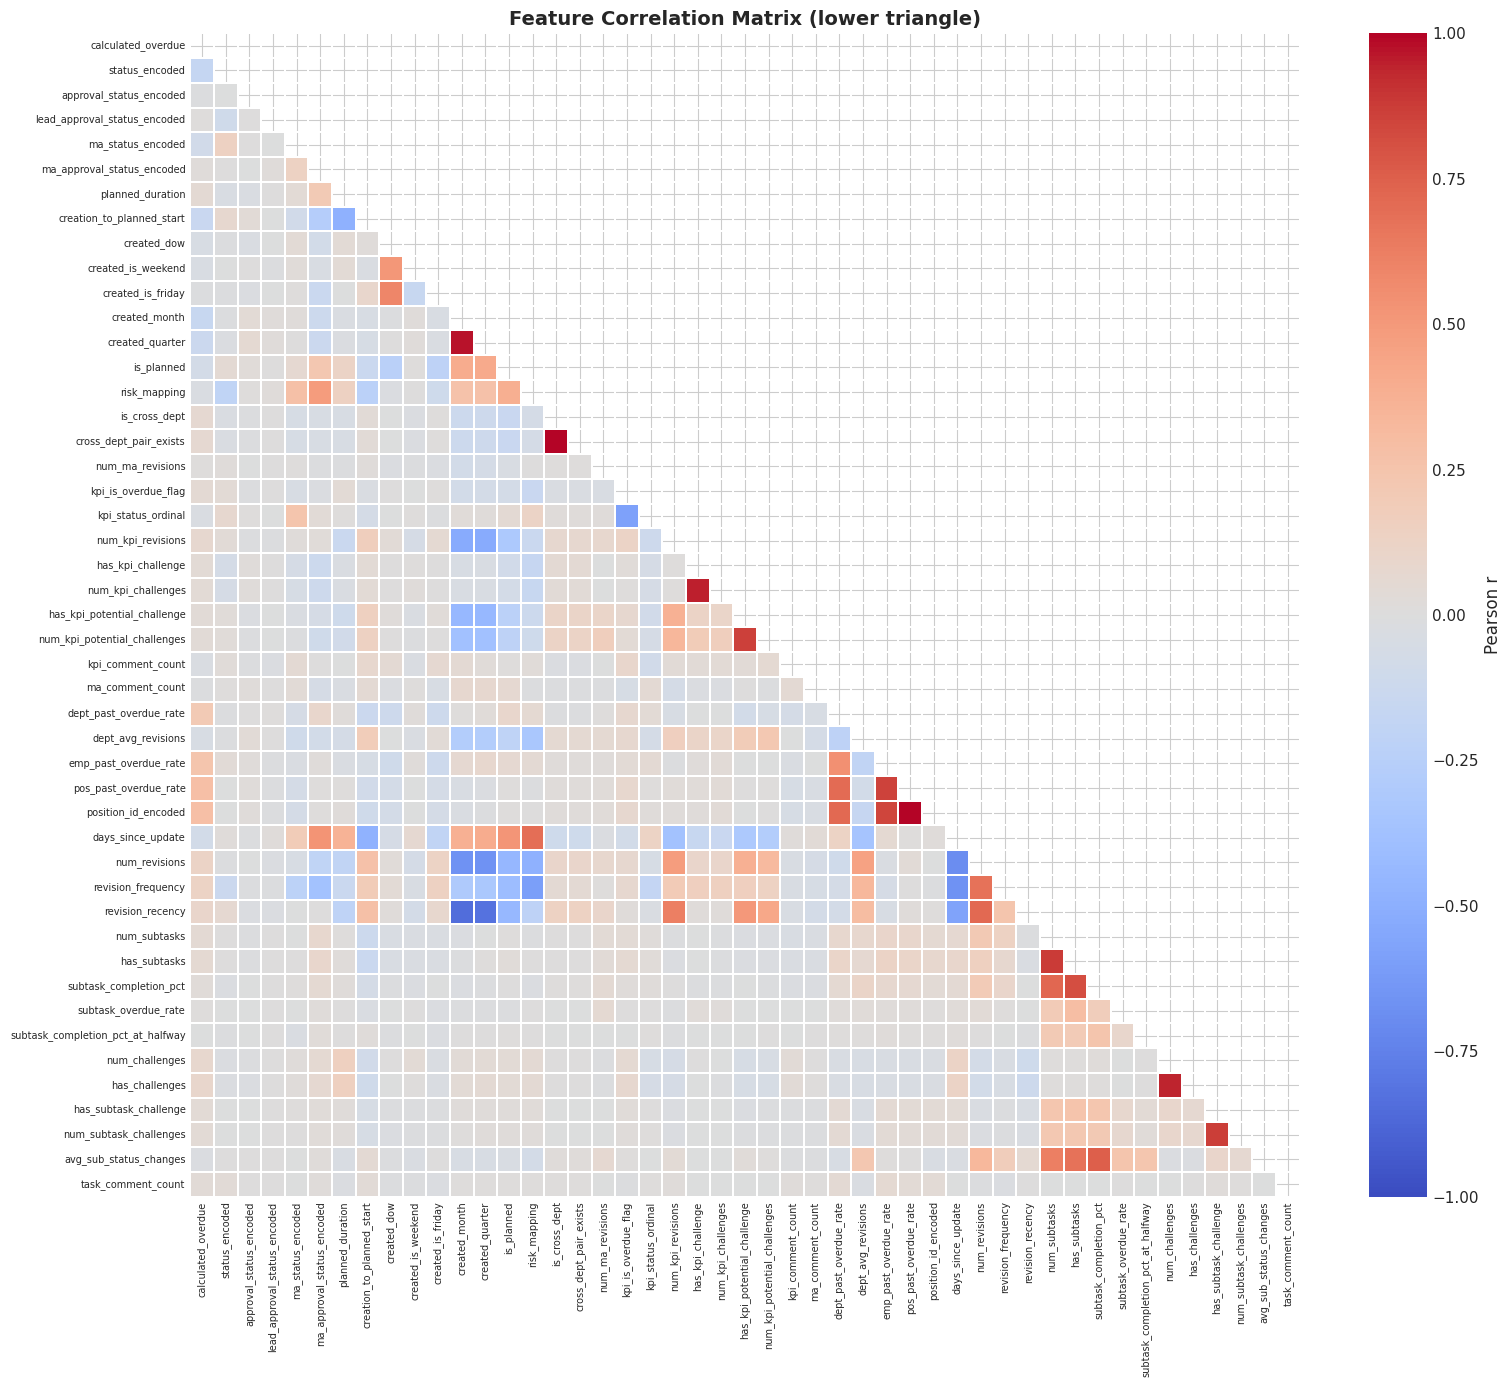

In [19]:
# Drop low-variance columns for cleaner heatmap
valid_cols = [c for c in num_df.columns if num_df[c].var() > 0.001]
corr_matrix = num_df[valid_cols].corr()

# Find highly correlated pairs
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.75:
            high_corr_pairs.append({
                'feature_A': corr_matrix.columns[i],
                'feature_B': corr_matrix.columns[j],
                'r': round(r, 3)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('r', ascending=False, key=abs)
print(f"Highly correlated feature pairs (|r| > 0.75) — consider dropping one per pair:")
print(high_corr_df.to_string(index=False))

# Heatmap of correlation matrix
fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.3, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Feature Correlation Matrix (lower triangle)', fontweight='bold')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()


### 11.8 Leakage Detection

Features that are computed from post-event data or encode the target indirectly are **leakage risks**. These must either be excluded or computed fold-safely within cross-validation.


In [20]:
leakage_analysis = {
    'status_encoded':              ('LEAKAGE RISK', 'status=completed is post-event — indicates task already finished'),
    'ma_status_encoded':           ('CAUTION',       'MA status reflects upstream resolution — fold-safe at creation time'),
    'dept_past_overdue_rate':      ('CAUTION',       'Must be recomputed inside each training fold — global mean leaks'),
    'emp_past_overdue_rate':       ('CAUTION',       'Must be recomputed inside each training fold — global mean leaks'),
    'pos_past_overdue_rate':       ('CAUTION',       'Must be recomputed inside each training fold — global mean leaks'),
    'position_id_encoded':         ('CAUTION',       'Target-encoded — must be fit on train fold only'),
    'days_since_update':           ('CAUTION',       'Uses today() — set fixed cutoff date for reproducibility'),
    'revision_recency':            ('CAUTION',       'Uses today() — same issue as days_since_update'),
    'subtask_completion_pct':      ('CAUTION',       'Current state — use subtask_completion_pct_at_halfway for strict halfway prediction'),
    'subtask_overdue_rate':        ('CAUTION',       'Current state — may include post-halfway events'),
    'num_revisions':               ('CAUTION',       'Current count — must be truncated at prediction cutoff'),
    'kpi_is_overdue_flag':         ('SAFE',          'KPI-level flag, not task-level — upstream signal only'),
    'ma_comment_count':            ('DROP',          'Dead feature: confirmed zero MA comments exist in dataset'),
    'planned_duration':            ('SAFE',          'Known at task creation — no leakage'),
    'creation_to_planned_start':   ('SAFE',          'Known at task creation — no leakage'),
    'risk_mapping':                ('SAFE',          'Domain-assigned at creation'),
    'is_cross_dept':               ('SAFE',          'Structural flag set at creation'),
    'is_planned':                  ('SAFE',          'Administrative flag set at creation'),
    'has_kpi_potential_challenge': ('SAFE',          'Planned challenges — known pre-execution'),
    'subtask_completion_pct_at_halfway': ('SAFE',   'Designed to be cutoff-safe — computed at theoretical midpoint'),
}

rows = [{'Feature': k, 'Verdict': v[0], 'Reason': v[1]} for k, v in leakage_analysis.items()]
leak_df = pd.DataFrame(rows)

colors = {'SAFE': '#2ca02c', 'CAUTION': '#ff7f0e', 'LEAKAGE RISK': '#d62728', 'DROP': '#7f7f7f'}
print("=== LEAKAGE RISK ASSESSMENT ===\n")
for verdict in ['LEAKAGE RISK', 'DROP', 'CAUTION', 'SAFE']:
    subset = leak_df[leak_df['Verdict'] == verdict]
    if not subset.empty:
        print(f"{'─'*60}")
        print(f"  {verdict} ({len(subset)} features)")
        print(f"{'─'*60}")
        for _, row in subset.iterrows():
            print(f"  • {row['Feature']:<40} | {row['Reason']}")
        print()


=== LEAKAGE RISK ASSESSMENT ===

────────────────────────────────────────────────────────────
  LEAKAGE RISK (1 features)
────────────────────────────────────────────────────────────
  • status_encoded                           | status=completed is post-event — indicates task already finished

────────────────────────────────────────────────────────────
  DROP (1 features)
────────────────────────────────────────────────────────────
  • ma_comment_count                         | Dead feature: confirmed zero MA comments exist in dataset

────────────────────────────────────────────────────────────
  CAUTION (10 features)
────────────────────────────────────────────────────────────
  • ma_status_encoded                        | MA status reflects upstream resolution — fold-safe at creation time
  • dept_past_overdue_rate                   | Must be recomputed inside each training fold — global mean leaks
  • emp_past_overdue_rate                    | Must be recomputed inside each train

### 11.9 Sparse Feature Analysis

High sparsity (>85% zeros) means a feature fires rarely. These features may still be useful when they fire (high precision), but they add noise for most rows.


Sparsity Analysis (% rows = 0):
                          feature  pct_zero  overdue_rate_when_nonzero                          verdict
subtask_completion_pct_at_halfway 99.856063                   0.200000                    CONSIDER DROP
           num_subtask_challenges 99.784095                   0.566667 KEEP (high precision when fires)
            has_subtask_challenge 99.784095                   0.566667 KEEP (high precision when fires)
             subtask_overdue_rate 99.654552                   0.333333 KEEP (high precision when fires)
               task_comment_count 99.582584                   0.396552 KEEP (high precision when fires)
          approval_status_encoded 99.057215                   0.160305                    CONSIDER DROP
                has_kpi_challenge 98.927672                   0.355705 KEEP (high precision when fires)
               num_kpi_challenges 98.927672                   0.355705 KEEP (high precision when fires)
                    is_cross_dep

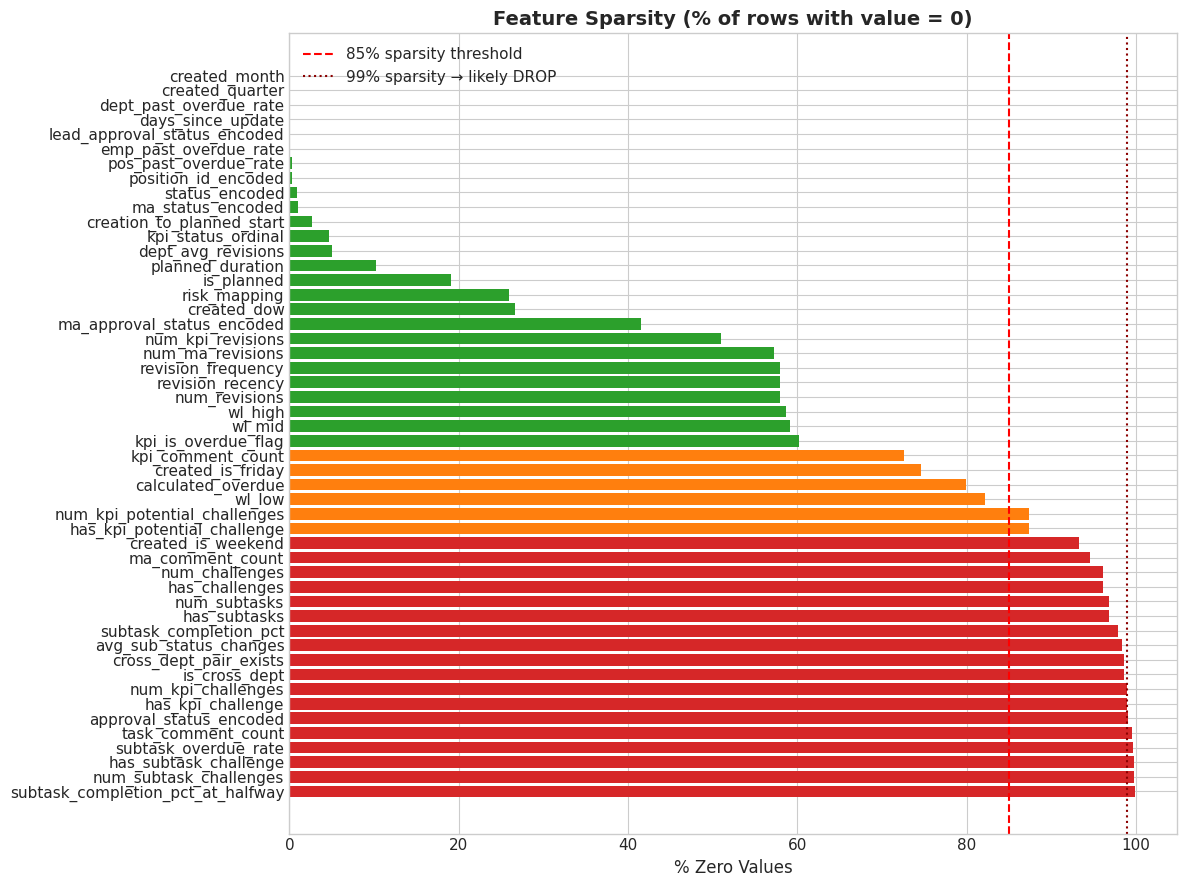

In [21]:
sparsity = (df[feat_cols] == 0).mean() * 100
sparse_df = sparsity.sort_values(ascending=False).reset_index()
sparse_df.columns = ['feature', 'pct_zero']
sparse_df['overdue_rate_when_nonzero'] = sparse_df['feature'].apply(
    lambda c: df[df[c] != 0]['calculated_overdue'].mean() if c in df.columns and df[c].dtype != object else np.nan
)
sparse_df['verdict'] = sparse_df.apply(lambda r:
    'KEEP (high precision when fires)' if r['pct_zero'] > 85 and r['overdue_rate_when_nonzero'] > 0.30
    else ('KEEP' if r['pct_zero'] <= 85
    else 'CONSIDER DROP'), axis=1)

print("Sparsity Analysis (% rows = 0):")
print(sparse_df[['feature', 'pct_zero', 'overdue_rate_when_nonzero', 'verdict']].to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 9))
colors_s = ['#d62728' if v > 90 else '#ff7f0e' if v > 70 else '#2ca02c' for v in sparse_df['pct_zero']]
ax.barh(sparse_df['feature'], sparse_df['pct_zero'], color=colors_s)
ax.axvline(85, color='red', linestyle='--', label='85% sparsity threshold')
ax.axvline(99, color='darkred', linestyle=':', label='99% sparsity → likely DROP')
ax.set_title('Feature Sparsity (% of rows with value = 0)', fontweight='bold')
ax.set_xlabel('% Zero Values')
ax.legend()
plt.tight_layout()
plt.show()


### 11.10 Final Feature Verdict Table — USE / CAUTION / AVOID

This is the **master feature selection decision table** combining signal strength, leakage risk, variance, and sparsity into a final recommendation for the modeling team.


In [22]:
corr_abs = num_df.corr()['calculated_overdue'].drop('calculated_overdue').abs()
variance_s = num_df.var()
sparsity_s = (df[feat_cols] == 0).mean() * 100

VERDICT_MAP = {
    # Strong USE
    'emp_past_overdue_rate':            ('USE',     'High signal (r=+0.24), fold-safe with proper CV'),
    'pos_past_overdue_rate':            ('USE',     'High signal (r=+0.28), fold-safe with proper CV'),
    'dept_past_overdue_rate':           ('USE',     'Strong dept-level signal, fold-safe with proper CV'),
    'position_id_encoded':              ('USE',     'Target-encoded, must be fit inside CV folds'),
    'planned_duration':                 ('USE',     'Strong temporal risk feature'),
    'creation_to_planned_start':        ('USE',     'Retroactive scheduling signal'),
    'num_revisions':                    ('USE',     'Strong revision death spiral signal'),
    'revision_frequency':               ('USE',     'Normalized revision rate'),
    'subtask_completion_pct_at_halfway':('USE',     'Designed to be cutoff-safe'),
    'kpi_is_overdue_flag':              ('USE',     'Upstream cascade risk signal'),
    'has_challenges':                   ('USE',     'Operational blocker signal'),
    'num_challenges':                   ('USE',     'Blocker intensity'),
    'is_cross_dept':                    ('USE',     'Structural coordination overhead'),
    'num_kpi_revisions':                ('USE',     'KPI churn indicator'),
    'num_ma_revisions':                 ('USE',     'Upstream MA process instability'),
    'task_comment_count':               ('USE',     'Communication paradox signal'),
    'days_since_update':                ('USE',     'Staleness indicator — fix cutoff date'),
    'created_month':                    ('USE',     'Seasonality — Q4 behavioral fatigue'),
    'created_quarter':                  ('USE',     'Coarse seasonality'),
    'is_planned':                       ('USE',     'Planned vs ad-hoc task risk'),
    'risk_mapping':                     ('USE',     'Domain-assigned risk tier'),
    'kpi_status_ordinal':               ('USE',     'Upstream KPI health'),
    'has_kpi_potential_challenge':      ('USE',     'Pre-planned blockers (~12.6% present)'),
    'num_kpi_potential_challenges':     ('USE',     'Planned blocker intensity'),
    # CAUTION
    'status_encoded':                   ('CAUTION', 'Post-event leakage risk for completed tasks — use only for in-flight prediction'),
    'subtask_completion_pct':           ('CAUTION', 'Current state — use _at_halfway variant for strict cutoff models'),
    'subtask_overdue_rate':             ('CAUTION', 'Current state — may include post-halfway data'),
    'revision_recency':                 ('CAUTION', 'Uses today() — fix cutoff date'),
    'approval_status_encoded':          ('CAUTION', 'Reflects post-review state, safe for halfway model'),
    'lead_approval_status_encoded':     ('CAUTION', 'Same as approval_status — second stage signal'),
    'ma_status_encoded':                ('CAUTION', 'Upstream state, safe at creation time'),
    'ma_approval_status_encoded':       ('CAUTION', 'Upstream approval state'),
    'has_kpi_challenge':                ('CAUTION', 'Very sparse (~1.1% present) — keep as precision feature'),
    'num_kpi_challenges':               ('CAUTION', 'Very sparse — same as above'),
    'has_subtask_challenge':            ('CAUTION', 'Extremely sparse (~0.2%) — monitor for overfitting'),
    'num_subtask_challenges':           ('CAUTION', 'Extremely sparse — same as above'),
    'cross_dept_pair_exists':           ('CAUTION', 'Very sparse (~1.4%) but informative when present'),
    'avg_sub_status_changes':           ('CAUTION', 'Sparse (~1.6% nonzero) — rework signal when present'),
    'num_subtasks':                     ('CAUTION', 'Current count may include post-halfway subtasks'),
    'has_subtasks':                     ('CAUTION', 'Current state subtask flag'),
    'subtask_completion_pct_at_halfway':('USE',     'Designed to be cutoff-safe — already marked USE'),
    # AVOID/DROP
    'ma_comment_count':                 ('AVOID',   'DEAD FEATURE: zero MA comments in entire dataset'),
    'created_is_weekend':               ('AVOID',   'Weak signal — very low overdue rate variance'),
    'created_is_friday':                ('AVOID',   'Marginal timing signal — low information gain'),
    'created_dow':                      ('AVOID',   'Subsumed by created_month/quarter; DOW effect minimal'),
    'kpi_comment_count':                ('AVOID',   'Extremely sparse (95% zero), signal subsumed by task_comment_count'),
    'wl_low':                           ('AVOID',   'Baseline dummy in one-hot set — causes dummy trap'),
}

rows = []
for feat in feat_cols:
    if feat == 'calculated_overdue':
        continue
    verdict, reason = VERDICT_MAP.get(feat, ('USE', 'Default — standard feature'))
    rows.append({
        'Feature': feat,
        'Verdict': verdict,
        'Abs_Corr_with_Target': round(corr_abs.get(feat, 0), 4),
        'Variance': round(variance_s.get(feat, 0), 4),
        'Sparsity_%': round(sparsity_s.get(feat, 0), 1),
        'Reason': reason
    })

verdict_df = pd.DataFrame(rows).sort_values(['Verdict', 'Abs_Corr_with_Target'], ascending=[True, False])

print("=" * 90)
print(f"{'FINAL FEATURE VERDICT TABLE':^90}")
print("=" * 90)
for verdict in ['USE', 'CAUTION', 'AVOID']:
    subset = verdict_df[verdict_df['Verdict'] == verdict]
    label = {'USE': '✅ USE', 'CAUTION': '⚠️  CAUTION', 'AVOID': '❌ AVOID / DROP'}[verdict]
    print(f"\n{label} — {len(subset)} features")
    print(f"{'─'*90}")
    print(subset[['Feature', 'Abs_Corr_with_Target', 'Sparsity_%', 'Reason']].to_string(index=False))

use_count = (verdict_df['Verdict'] == 'USE').sum()
caution_count = (verdict_df['Verdict'] == 'CAUTION').sum()
avoid_count = (verdict_df['Verdict'] == 'AVOID').sum()
print(f"\n{'─'*90}")
print(f"SUMMARY: ✅ USE={use_count}  |  ⚠️  CAUTION={caution_count}  |  ❌ AVOID={avoid_count}")
print(f"Recommended minimum feature set for baseline model: {use_count} features")


                               FINAL FEATURE VERDICT TABLE                                

✅ USE — 27 features
──────────────────────────────────────────────────────────────────────────────────────────
                          Feature  Abs_Corr_with_Target  Sparsity_%                                             Reason
              position_id_encoded                0.2877         0.3        Target-encoded, must be fit inside CV folds
            pos_past_overdue_rate                0.2855         0.3    High signal (r=+0.28), fold-safe with proper CV
            emp_past_overdue_rate                0.2434         0.1    High signal (r=+0.24), fold-safe with proper CV
           dept_past_overdue_rate                0.2061         0.0 Strong dept-level signal, fold-safe with proper CV
                    created_month                0.1515         0.0                Seasonality — Q4 behavioral fatigue
        creation_to_planned_start                0.1425         2.7                

### 11.11 Signal vs. Sparsity Scatter — Feature Landscape

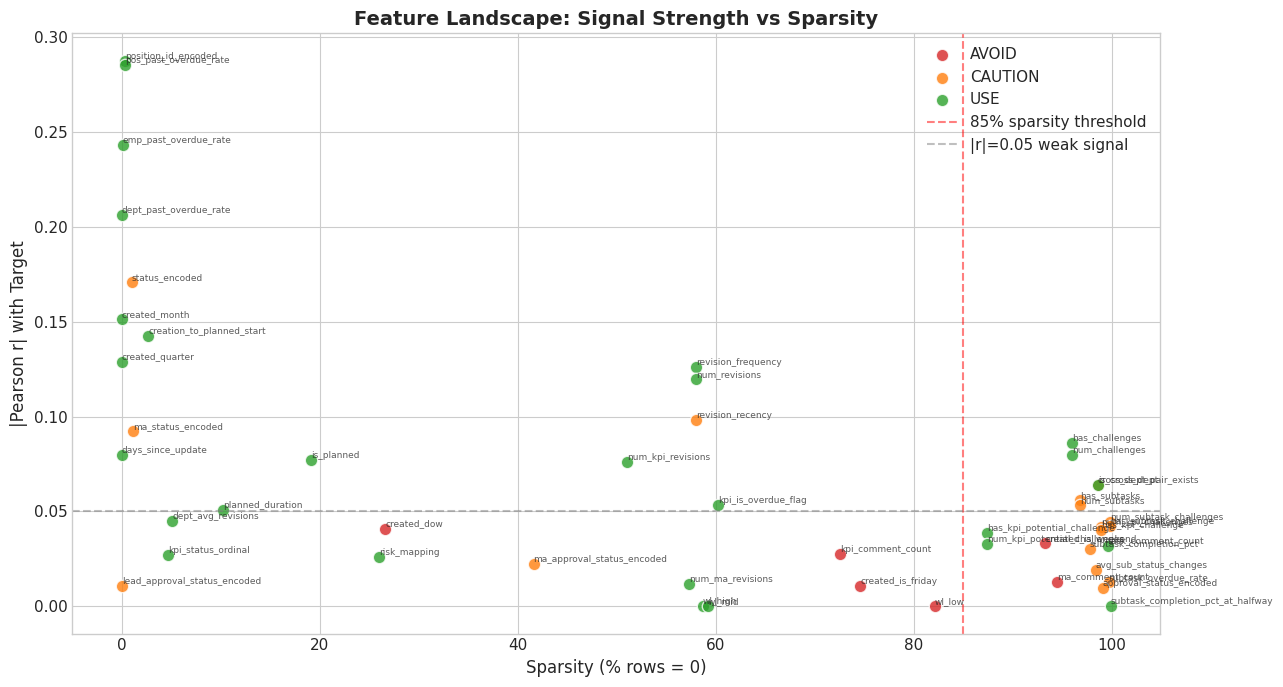

In [23]:
plot_df = verdict_df.copy()
plot_df['corr'] = plot_df['Abs_Corr_with_Target']
plot_df['sparsity'] = plot_df['Sparsity_%']

color_map = {'USE': '#2ca02c', 'CAUTION': '#ff7f0e', 'AVOID': '#d62728'}
fig, ax = plt.subplots(figsize=(13, 7))
for verdict, grp in plot_df.groupby('Verdict'):
    ax.scatter(grp['sparsity'], grp['corr'], label=verdict,
               color=color_map[verdict], s=80, alpha=0.8, edgecolors='white')
    for _, row in grp.iterrows():
        ax.annotate(row['Feature'], (row['sparsity'], row['corr']),
                    fontsize=6.5, ha='left', va='bottom', alpha=0.75)

ax.axvline(85, color='red', linestyle='--', alpha=0.5, label='85% sparsity threshold')
ax.axhline(0.05, color='gray', linestyle='--', alpha=0.5, label='|r|=0.05 weak signal')
ax.set_title('Feature Landscape: Signal Strength vs Sparsity', fontweight='bold', fontsize=14)
ax.set_xlabel('Sparsity (% rows = 0)', fontsize=12)
ax.set_ylabel('|Pearson r| with Target', fontsize=12)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


## 12. Creation-Time vs Halfway: Signal Comparison

**Goal:** Determine how much additional predictive signal the 15 halfway accumulation features add
over the 36 creation-time features. This guides which dataset to use for each model variant.

- **Creation model** (`dataset_at_creation.csv`): Predicts risk at task assignment (T=0).
- **Halfway model** (`dataset_at_halfway.csv`): Predicts risk mid-execution with in-flight data.


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

df_hw = pd.read_csv('../data/v1/dataset_at_halfway.csv')
df_cr = pd.read_csv('../data/v1/dataset_at_creation.csv')

TARGET = 'calculated_overdue'

# Features only in the halfway dataset (the 15 accumulation features)
creation_feats = [c for c in df_cr.columns if c not in ['id', TARGET]]
halfway_only_feats = [c for c in df_hw.columns if c not in df_cr.columns and c not in ['id', TARGET]]

print(f"Creation-time features : {len(creation_feats)}")
print(f"Halfway-only features  : {len(halfway_only_feats)}")
print(f"Halfway-only list      : {halfway_only_feats}")


Creation-time features : 34
Halfway-only features  : 15
Halfway-only list      : ['days_since_update', 'num_revisions', 'revision_frequency', 'revision_recency', 'num_subtasks', 'has_subtasks', 'subtask_completion_pct', 'subtask_overdue_rate', 'subtask_completion_pct_at_halfway', 'num_challenges', 'has_challenges', 'has_subtask_challenge', 'num_subtask_challenges', 'avg_sub_status_changes', 'task_comment_count']


In [25]:
# Pearson correlation of each feature group with the target
def get_correlations(df, feature_list, target):
    corr_data = []
    for col in feature_list:
        r, p = stats.pearsonr(df[col], df[target])
        corr_data.append({'feature': col, 'pearson_r': r, 'abs_r': abs(r), 'p_value': p})
    return pd.DataFrame(corr_data).sort_values('abs_r', ascending=False)

creation_corr = get_correlations(df_cr, creation_feats, TARGET)
halfway_corr  = get_correlations(df_hw, halfway_only_feats, TARGET)

print("=== Top 10 Creation-Time Features by Signal Strength ===")
print(creation_corr[['feature', 'pearson_r', 'abs_r']].head(10).to_string(index=False))
print()
print("=== Halfway Accumulation Features by Signal Strength ===")
print(halfway_corr[['feature', 'pearson_r', 'abs_r']].to_string(index=False))


=== Top 10 Creation-Time Features by Signal Strength ===
                  feature  pearson_r    abs_r
      position_id_encoded   0.287728 0.287728
    pos_past_overdue_rate   0.285498 0.285498
    emp_past_overdue_rate   0.243434 0.243434
   dept_past_overdue_rate   0.206075 0.206075
           status_encoded  -0.171015 0.171015
            created_month  -0.151466 0.151466
creation_to_planned_start  -0.142469 0.142469
          created_quarter  -0.128657 0.128657
        ma_status_encoded  -0.092434 0.092434
               is_planned  -0.077196 0.077196

=== Halfway Accumulation Features by Signal Strength ===
                          feature  pearson_r    abs_r
               revision_frequency   0.126374 0.126374
                    num_revisions   0.119555 0.119555
                 revision_recency   0.098272 0.098272
                   has_challenges   0.086328 0.086328
                   num_challenges   0.079968 0.079968
                days_since_update  -0.079916 0.079916
 

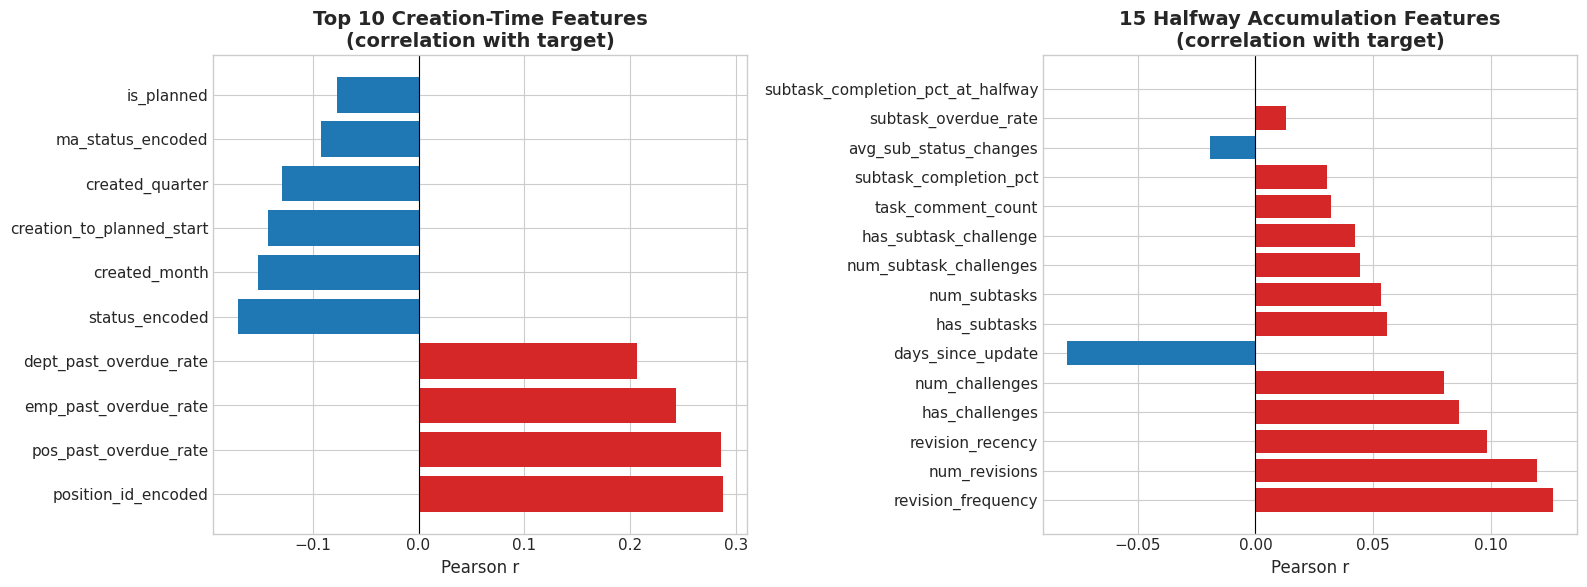

Creation-time  — best |r|: 0.288 | mean |r|: 0.077
Halfway-only   — best |r|: 0.126  | mean |r|: 0.059

Conclusion: Halfway features add measurable incremental signal.


In [26]:
# Side-by-side bar chart: top 10 creation features vs all 15 halfway features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_creation = creation_corr.head(10)
axes[0].barh(top_creation['feature'], top_creation['pearson_r'],
             color=['#d62728' if v > 0 else '#1f77b4' for v in top_creation['pearson_r']])
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Top 10 Creation-Time Features\n(correlation with target)', fontweight='bold')
axes[0].set_xlabel('Pearson r')

axes[1].barh(halfway_corr['feature'], halfway_corr['pearson_r'],
             color=['#d62728' if v > 0 else '#1f77b4' for v in halfway_corr['pearson_r']])
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('15 Halfway Accumulation Features\n(correlation with target)', fontweight='bold')
axes[1].set_xlabel('Pearson r')

plt.tight_layout()
plt.show()

# Summary
best_creation  = creation_corr['abs_r'].max()
best_halfway   = halfway_corr['abs_r'].max()
mean_creation  = creation_corr['abs_r'].mean()
mean_halfway   = halfway_corr['abs_r'].mean()

print(f"Creation-time  — best |r|: {best_creation:.3f} | mean |r|: {mean_creation:.3f}")
print(f"Halfway-only   — best |r|: {best_halfway:.3f}  | mean |r|: {mean_halfway:.3f}")
print()
print("Conclusion: Halfway features add measurable incremental signal." if mean_halfway > 0.05
      else "Conclusion: Halfway features add limited incremental signal over creation features.")


## 13. Data Quality Anomalies and Outlier Handling

`handoff.md` documents two known anomalies:
1. **Negative planned duration**: 2 tasks where `end_date < start_date` (data entry errors).
2. **Extreme revision outlier**: 1 task with `num_ma_revisions = 247,161` (system logging loop).

This section identifies, quantifies, and applies capping so distance-based or linear models
are not distorted. Tree-based models (XGBoost, RF) are robust to these, but we cap anyway
for consistency across model families.


In [27]:
df = pd.read_csv('../data/v1/dataset_at_halfway.csv')

# --- 1. Negative planned duration ---
neg_dur = df[df['planned_duration'] < 0]
print(f"Tasks with negative planned_duration: {len(neg_dur)}")
print(neg_dur[['id', 'planned_duration', 'calculated_overdue']].to_string(index=False))


Tasks with negative planned_duration: 2
                                  id  planned_duration  calculated_overdue
ca3217e4-436f-42f7-97d1-f248cb39cc6f               -41                   1
1d90245b-7d17-40f1-8c78-0d7d6e658530               -11                   0


In [28]:
# --- 2. Extreme revision outlier ---
rev_stats = df['num_ma_revisions'].describe(percentiles=[0.90, 0.95, 0.99])
print("num_ma_revisions distribution:")
print(rev_stats.to_string())
print()
print(f"Tasks with num_ma_revisions > 1000: {(df['num_ma_revisions'] > 1000).sum()}")
print(f"Max value: {df['num_ma_revisions'].max():,}")


num_ma_revisions distribution:
count     13895.000000
mean        441.273696
std        9368.883284
min           0.000000
50%           0.000000
90%          20.000000
95%          35.000000
99%          78.000000
max      247161.000000

Tasks with num_ma_revisions > 1000: 41
Max value: 247,161


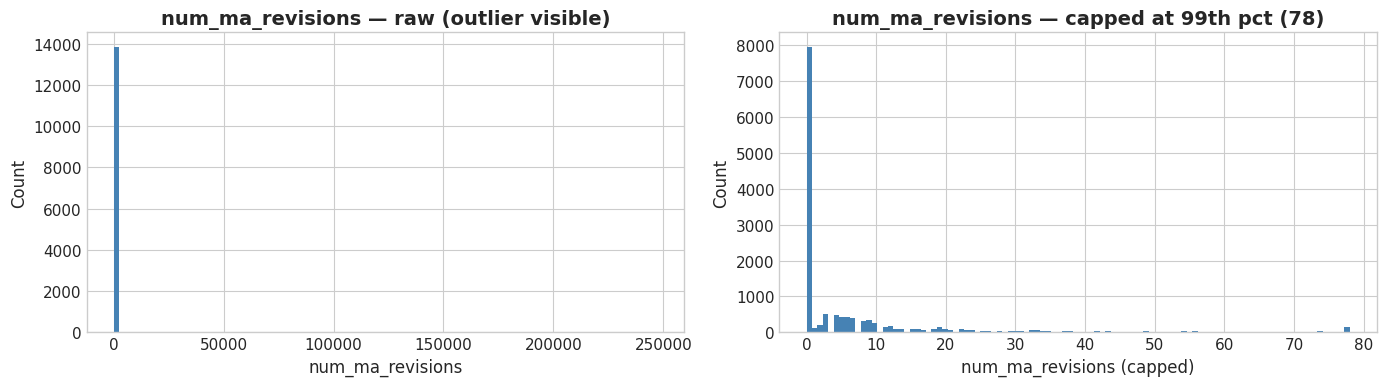

In [29]:
# --- 3. Visualise the outlier effect ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['num_ma_revisions'], bins=100, color='steelblue')
axes[0].set_title('num_ma_revisions — raw (outlier visible)', fontweight='bold')
axes[0].set_xlabel('num_ma_revisions')
axes[0].set_ylabel('Count')

# After capping at 99th percentile
cap_99 = df['num_ma_revisions'].quantile(0.99)
capped = df['num_ma_revisions'].clip(upper=cap_99)
axes[1].hist(capped, bins=100, color='steelblue')
axes[1].set_title(f'num_ma_revisions — capped at 99th pct ({cap_99:.0f})', fontweight='bold')
axes[1].set_xlabel('num_ma_revisions (capped)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


In [30]:
# --- 4. Recommended cleaning decisions ---
print("=== Recommended Cleaning Decisions ===")
print()
print("1. planned_duration < 0 (2 tasks):")
print("   Action: Clip to 0. These are data entry errors (end_date < start_date).")
print("   Impact: Negligible (0.014% of data). Do NOT drop rows.")
print()
cap_99 = df['num_ma_revisions'].quantile(0.99)
print(f"2. num_ma_revisions outlier (max = 247,161):")
print(f"   Action: Cap at 99th percentile = {cap_99:.0f}.")
print(f"   Impact: Affects {(df['num_ma_revisions'] > cap_99).sum()} rows.")
print()
print("3. num_revisions — check for similar outliers:")
rev99 = df['num_revisions'].quantile(0.99)
print(f"   99th pct = {rev99:.0f} | max = {df['num_revisions'].max()}")
print(f"   Rows above 99th pct: {(df['num_revisions'] > rev99).sum()}")
print()
print("Apply these caps before training. Tree models are robust but capping keeps")
print("the feature space clean for all model families including linear and kNN.")


=== Recommended Cleaning Decisions ===

1. planned_duration < 0 (2 tasks):
   Action: Clip to 0. These are data entry errors (end_date < start_date).
   Impact: Negligible (0.014% of data). Do NOT drop rows.

2. num_ma_revisions outlier (max = 247,161):
   Action: Cap at 99th percentile = 78.
   Impact: Affects 137 rows.

3. num_revisions — check for similar outliers:
   99th pct = 9 | max = 38
   Rows above 99th pct: 126

Apply these caps before training. Tree models are robust but capping keeps
the feature space clean for all model families including linear and kNN.


## 14. Department-Wise Overdue Breakdown

The raw `department_id` is not in the analytical dataset — it was encoded into `dept_past_overdue_rate`
and `dept_avg_revisions` aggregate features. We use these to reconstruct department-level risk buckets
and identify which departments are systematically over-performing or under-performing.

**Note:** Since the CSV does not include raw `department_id`, we bin `dept_past_overdue_rate` into risk
tiers to identify high-risk vs low-risk department groups.


In [31]:
df = pd.read_csv('../data/v1/dataset_at_halfway.csv')

# Distribution of department-level overdue rates
print("dept_past_overdue_rate distribution:")
print(df['dept_past_overdue_rate'].describe().to_string())
print()
print(f"Unique department overdue rate values: {df['dept_past_overdue_rate'].nunique()}")


dept_past_overdue_rate distribution:
count    13895.000000
mean         0.201008
std          0.082588
min          0.034749
25%          0.154691
50%          0.168994
75%          0.225225
max          1.000000

Unique department overdue rate values: 25


In [32]:
# Bin departments into risk tiers based on their historical overdue rate
bins   = [0.0, 0.10, 0.20, 0.30, 1.01]
labels = ['Low Risk (0-10%)', 'Moderate (10-20%)', 'High (20-30%)', 'Critical (>30%)']

df['dept_risk_tier'] = pd.cut(df['dept_past_overdue_rate'], bins=bins, labels=labels, include_lowest=True)

tier_summary = (df.groupby('dept_risk_tier', observed=True)
                  .agg(
                      num_tasks=('calculated_overdue', 'count'),
                      actual_overdue_rate=('calculated_overdue', 'mean'),
                      dept_hist_rate_mean=('dept_past_overdue_rate', 'mean')
                  )
                  .reset_index())

tier_summary['actual_overdue_pct'] = (tier_summary['actual_overdue_rate'] * 100).round(1)
print(tier_summary[['dept_risk_tier', 'num_tasks', 'dept_hist_rate_mean', 'actual_overdue_pct']].to_string(index=False))


   dept_risk_tier  num_tasks  dept_hist_rate_mean  actual_overdue_pct
 Low Risk (0-10%)        259             0.034749                 3.5
Moderate (10-20%)       7976             0.152708                15.3
    High (20-30%)       3183             0.218976                21.9
  Critical (>30%)       2477             0.350828                35.1


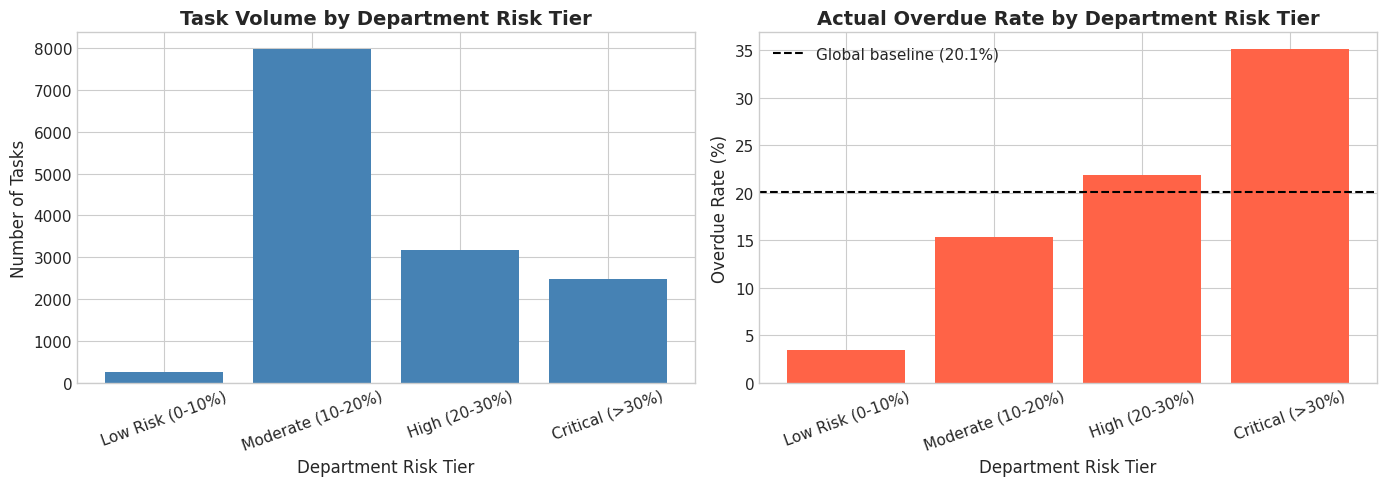

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: task volume per department risk tier
axes[0].bar(tier_summary['dept_risk_tier'], tier_summary['num_tasks'], color='steelblue')
axes[0].set_title('Task Volume by Department Risk Tier', fontweight='bold')
axes[0].set_xlabel('Department Risk Tier')
axes[0].set_ylabel('Number of Tasks')
axes[0].tick_params(axis='x', rotation=20)

# Right: actual overdue rate per tier
axes[1].bar(tier_summary['dept_risk_tier'], tier_summary['actual_overdue_pct'], color='tomato')
axes[1].axhline(df['calculated_overdue'].mean() * 100, color='black',
                linestyle='--', label=f"Global baseline ({df['calculated_overdue'].mean()*100:.1f}%)")
axes[1].set_title('Actual Overdue Rate by Department Risk Tier', fontweight='bold')
axes[1].set_xlabel('Department Risk Tier')
axes[1].set_ylabel('Overdue Rate (%)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


Overdue rate (%) by Department Risk Tier x Task Weight Level:
weight_category         High        Low        Mid
dept_risk_tier                                    
Low Risk (0-10%)    3.867403   0.000000   2.857143
Moderate (10-20%)  15.461099  12.368728  15.826873
High (20-30%)      21.904762  26.439024  18.622628
Critical (>30%)    37.125000  39.898990  30.932595


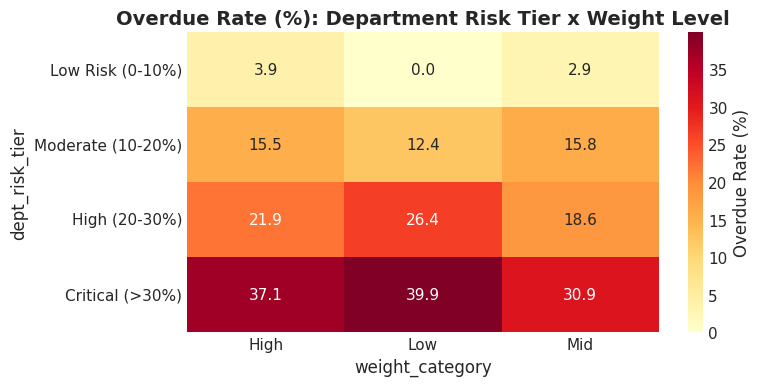

In [34]:
# Cross: dept_risk_tier vs weight level — which departments AND priorities are problematic
# Recreate weight_category since each section loads df fresh
df['weight_category'] = 'Low'
df.loc[df['wl_mid'] == 1, 'weight_category'] = 'Mid'
df.loc[df['wl_high'] == 1, 'weight_category'] = 'High'

pivot = (df.pivot_table(index='dept_risk_tier', columns='weight_category',
                        values='calculated_overdue', aggfunc='mean', observed=True) * 100)

print("Overdue rate (%) by Department Risk Tier x Task Weight Level:")
print(pivot.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Overdue Rate (%)'})
ax.set_title('Overdue Rate (%): Department Risk Tier x Weight Level', fontweight='bold')
plt.tight_layout()
plt.show()


## 15. Challenge Count Depth Analysis

The dataset encodes challenges as counts and binary flags (`has_challenges`, `num_challenges`,
`has_kpi_challenge`, etc.). Since the raw challenge type labels are in the source database
(not the analytical CSV), we do a depth analysis on:
- How overdue rate scales with increasing challenge counts.
- Which challenge type (task-level vs KPI-level vs subtask-level) carries the strongest signal.
- Combined challenge load (task + KPI + subtask challenges) as a composite risk score.


In [35]:
df = pd.read_csv('../data/v1/dataset_at_halfway.csv')

# Overdue rate at each challenge count level
challenge_summary = (df.groupby('num_challenges')['calculated_overdue']
                       .agg(num_tasks='count', overdue_rate='mean')
                       .reset_index())
challenge_summary['overdue_pct'] = (challenge_summary['overdue_rate'] * 100).round(1)

print("Overdue rate by number of task-level challenges:")
print(challenge_summary[['num_challenges', 'num_tasks', 'overdue_pct']].to_string(index=False))


Overdue rate by number of task-level challenges:
 num_challenges  num_tasks  overdue_pct
              0      13346         19.4
              1        495         36.8
              2         42         47.6
              3         10         20.0
              4          2          0.0


In [36]:
# Compare overdue rates across all three challenge types
challenge_types = {
    'Task Challenge':         'has_challenges',
    'KPI Challenge':          'has_kpi_challenge',
    'Subtask Challenge':      'has_subtask_challenge',
    'KPI Potential Challenge':'has_kpi_potential_challenge',
}

rows = []
for label, col in challenge_types.items():
    pct_present = df[col].mean() * 100
    rate_present = df[df[col] == 1]['calculated_overdue'].mean() * 100
    rate_absent  = df[df[col] == 0]['calculated_overdue'].mean() * 100
    lift = rate_present / rate_absent if rate_absent > 0 else 0
    rows.append({
        'Challenge Type': label,
        '% Tasks Affected': round(pct_present, 1),
        'Overdue Rate When Present (%)': round(rate_present, 1),
        'Overdue Rate When Absent (%)':  round(rate_absent, 1),
        'Lift': round(lift, 2),
    })

comparison_df = pd.DataFrame(rows)
print("Challenge Type Signal Comparison:")
print(comparison_df.to_string(index=False))


Challenge Type Signal Comparison:
         Challenge Type  % Tasks Affected  Overdue Rate When Present (%)  Overdue Rate When Absent (%)  Lift
         Task Challenge               4.0                           37.2                          19.4  1.92
          KPI Challenge               1.1                           35.6                          19.9  1.78
      Subtask Challenge               0.2                           56.7                          20.0  2.83
KPI Potential Challenge              12.6                           24.2                          19.5  1.24


Overdue rate by composite challenge load (0 = no challenge flags, 4 = all flags set):
 total_challenge_load  num_tasks  overdue_pct
                    0      11519         18.5
                    1       2273         27.7
                    2         99         31.3
                    3          4         50.0


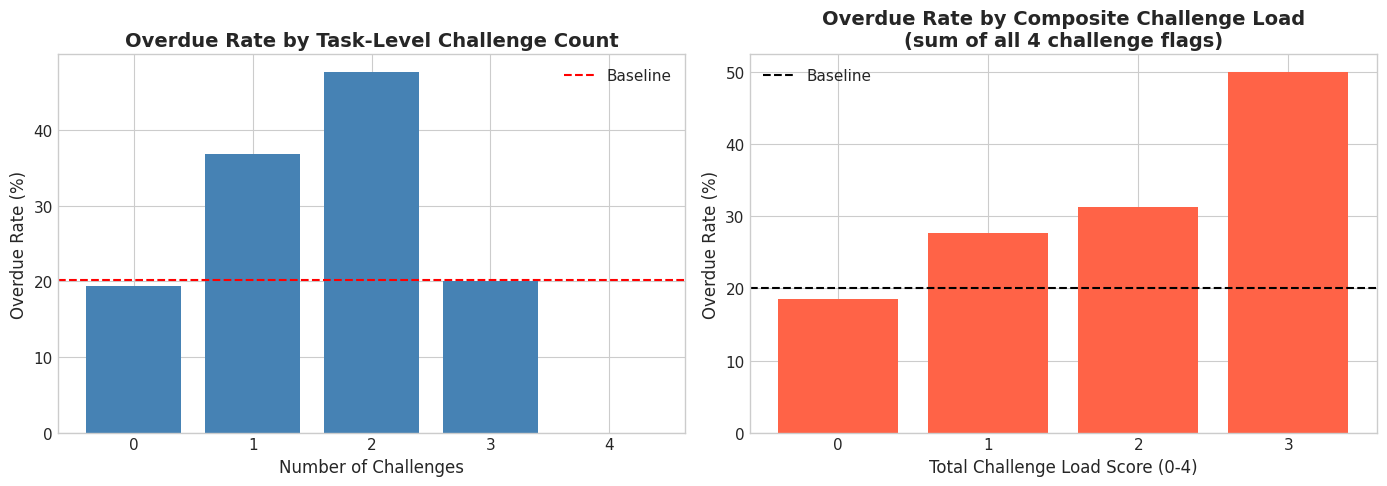

In [37]:
# Composite challenge load score = sum of all challenge flags
df['total_challenge_load'] = (df['has_challenges'] + df['has_kpi_challenge'] +
                               df['has_subtask_challenge'] + df['has_kpi_potential_challenge'])

load_summary = (df.groupby('total_challenge_load')['calculated_overdue']
                  .agg(num_tasks='count', overdue_rate='mean')
                  .reset_index())
load_summary['overdue_pct'] = (load_summary['overdue_rate'] * 100).round(1)

print("Overdue rate by composite challenge load (0 = no challenge flags, 4 = all flags set):")
print(load_summary[['total_challenge_load', 'num_tasks', 'overdue_pct']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overdue rate by num_challenges
axes[0].bar(challenge_summary['num_challenges'].astype(str),
            challenge_summary['overdue_pct'], color='steelblue')
axes[0].axhline(df['calculated_overdue'].mean() * 100, color='red',
                linestyle='--', label='Baseline')
axes[0].set_title('Overdue Rate by Task-Level Challenge Count', fontweight='bold')
axes[0].set_xlabel('Number of Challenges')
axes[0].set_ylabel('Overdue Rate (%)')
axes[0].legend()

# Right: overdue rate by composite load
axes[1].bar(load_summary['total_challenge_load'].astype(str),
            load_summary['overdue_pct'], color='tomato')
axes[1].axhline(df['calculated_overdue'].mean() * 100, color='black',
                linestyle='--', label='Baseline')
axes[1].set_title('Overdue Rate by Composite Challenge Load\n(sum of all 4 challenge flags)', fontweight='bold')
axes[1].set_xlabel('Total Challenge Load Score (0-4)')
axes[1].set_ylabel('Overdue Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.show()


## 16. Temporal Distribution and Train/Test Split Validation

**Goal:** Determine whether a **time-based split** (train on early tasks, test on later tasks)
is necessary to prevent temporal leakage, or whether **Stratified K-Fold** is safe.

The dataset does not retain raw `created_date`, but `created_month` and `created_quarter`
encode temporal position. We analyse:
1. Task volume and overdue rate distribution across months and quarters.
2. Whether overdue rates are stable over time (stable → K-Fold is safe) or drifting (drifting → time-split required).
3. Recommendation on split strategy.


In [38]:
df = pd.read_csv('../data/v1/dataset_at_halfway.csv')

# Task volume and overdue rate by month
monthly = (df.groupby('created_month')['calculated_overdue']
             .agg(num_tasks='count', overdue_rate='mean')
             .reset_index())
monthly['overdue_pct'] = (monthly['overdue_rate'] * 100).round(1)

print("Task volume and overdue rate by creation month:")
print(monthly.to_string(index=False))


Task volume and overdue rate by creation month:
 created_month  num_tasks  overdue_rate  overdue_pct
             1        965      0.262176         26.2
             2       1211      0.257638         25.8
             3        893      0.298992         29.9
             4       1210      0.190909         19.1
             5       1270      0.152756         15.3
             6       1480      0.188514         18.9
             7        865      0.663584         66.4
             8       1623      0.218115         21.8
             9       1305      0.104215         10.4
            10       1325      0.074717          7.5
            11        969      0.055728          5.6
            12        779      0.051348          5.1


In [39]:
# Task volume and overdue rate by quarter
quarterly = (df.groupby('created_quarter')['calculated_overdue']
               .agg(num_tasks='count', overdue_rate='mean')
               .reset_index())
quarterly['overdue_pct'] = (quarterly['overdue_rate'] * 100).round(1)

print("Task volume and overdue rate by creation quarter:")
print(quarterly.to_string(index=False))


Task volume and overdue rate by creation quarter:
 created_quarter  num_tasks  overdue_rate  overdue_pct
               1       3069      0.271098         27.1
               2       3960      0.177778         17.8
               3       3793      0.280517         28.1
               4       3073      0.062805          6.3


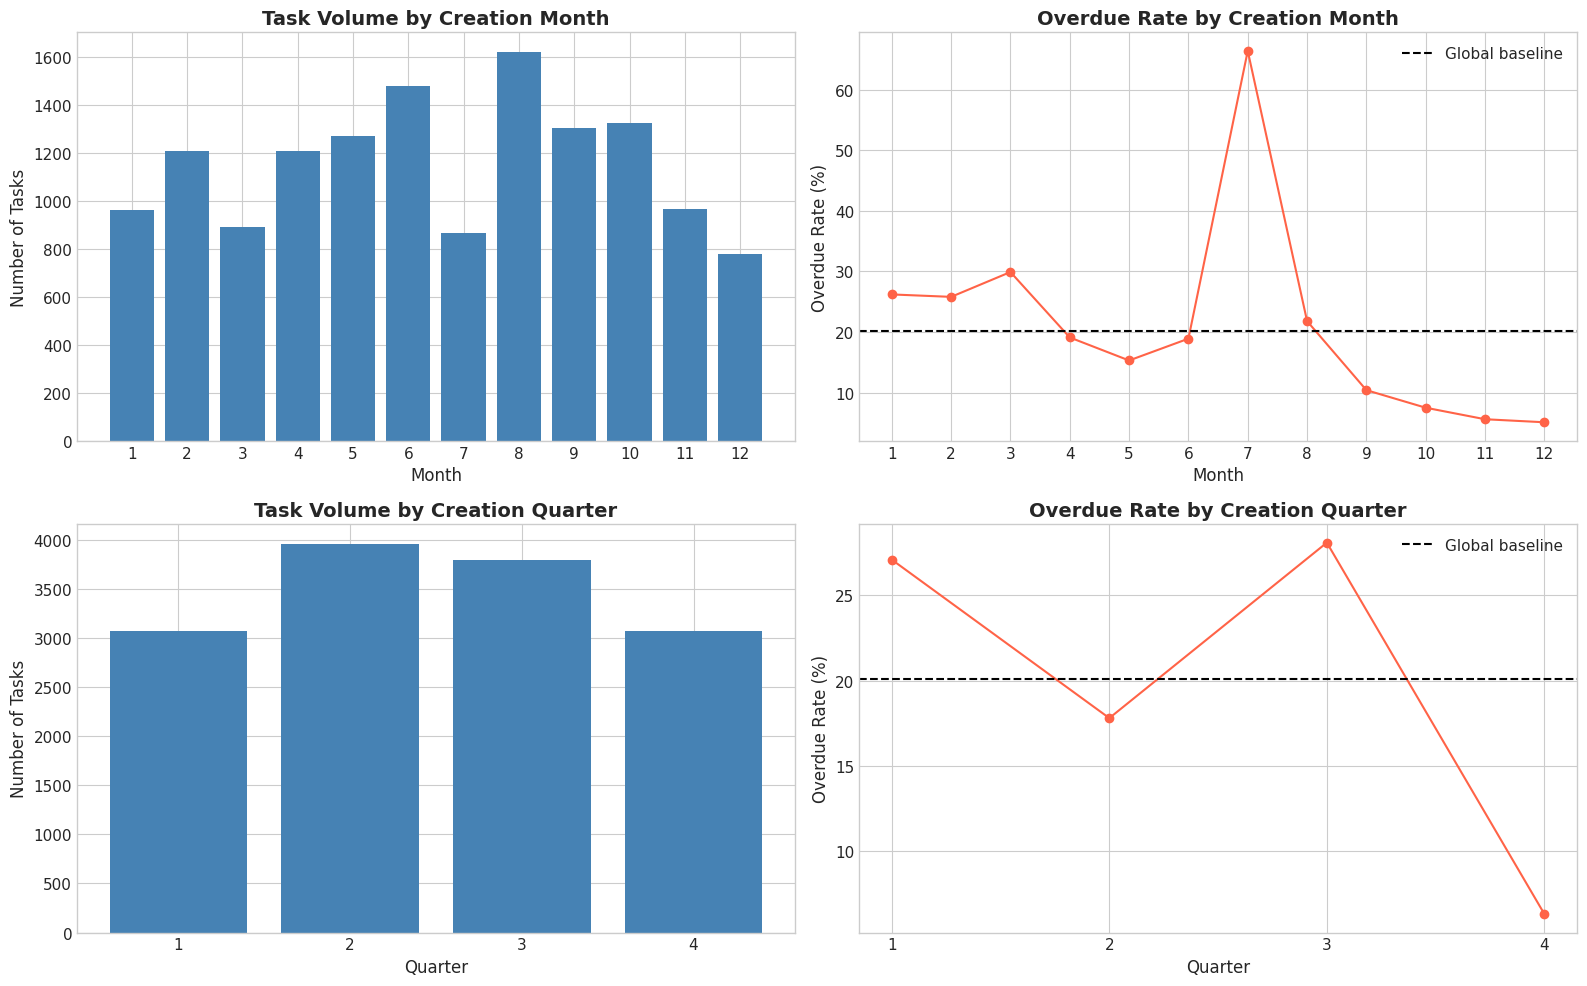

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Monthly volume
axes[0, 0].bar(monthly['created_month'], monthly['num_tasks'], color='steelblue')
axes[0, 0].set_title('Task Volume by Creation Month', fontweight='bold')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Number of Tasks')
axes[0, 0].set_xticks(range(1, 13))

# Monthly overdue rate
axes[0, 1].plot(monthly['created_month'], monthly['overdue_pct'], marker='o', color='tomato')
axes[0, 1].axhline(df['calculated_overdue'].mean() * 100, color='black',
                   linestyle='--', label='Global baseline')
axes[0, 1].set_title('Overdue Rate by Creation Month', fontweight='bold')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Overdue Rate (%)')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].legend()

# Quarterly volume
axes[1, 0].bar(quarterly['created_quarter'].astype(str), quarterly['num_tasks'], color='steelblue')
axes[1, 0].set_title('Task Volume by Creation Quarter', fontweight='bold')
axes[1, 0].set_xlabel('Quarter')
axes[1, 0].set_ylabel('Number of Tasks')

# Quarterly overdue rate
axes[1, 1].plot(quarterly['created_quarter'].astype(str), quarterly['overdue_pct'],
                marker='o', color='tomato')
axes[1, 1].axhline(df['calculated_overdue'].mean() * 100, color='black',
                   linestyle='--', label='Global baseline')
axes[1, 1].set_title('Overdue Rate by Creation Quarter', fontweight='bold')
axes[1, 1].set_xlabel('Quarter')
axes[1, 1].set_ylabel('Overdue Rate (%)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


In [41]:
# Statistical test: is overdue rate stable across quarters?
# Chi-squared test on quarter vs overdue contingency table
ct = pd.crosstab(df['created_quarter'], df['calculated_overdue'])
chi2, p, dof, _ = stats.chi2_contingency(ct)

print(f"Chi-squared test: overdue rate vs creation quarter")
print(f"  chi2 = {chi2:.2f}, p-value = {p:.4f}, dof = {dof}")
print()

if p < 0.05:
    print("Result: SIGNIFICANT difference in overdue rates across quarters (p < 0.05).")
    print("        This means overdue risk is NOT uniformly distributed over time.")
else:
    print("Result: No significant difference across quarters. K-Fold is safe.")

print()
print("=== Train/Test Split Recommendation ===")
print()
print("Option A — Stratified K-Fold (5 folds, stratify on target):")
print("  Pros: Maximises training data, stable CV estimates.")
print("  Cons: Mixes temporal cohorts; may overestimate performance if")
print("        future data behaves differently from past data.")
print()
print("Option B — Time-Based Split (train on early months, test on later months):")
print("  Pros: Realistic simulation of production deployment.")
print("  Cons: Requires raw created_date (not in current CSV) or using")
print("        created_month/quarter as a proxy for ordering.")
print()
print("Recommendation: Use Stratified K-Fold for model selection and tuning.")
print("Validate final model on a held-out temporal slice (last 2 months of data)")
print("to confirm the model generalises to future tasks.")


Chi-squared test: overdue rate vs creation quarter
  chi2 = 621.94, p-value = 0.0000, dof = 3

Result: SIGNIFICANT difference in overdue rates across quarters (p < 0.05).
        This means overdue risk is NOT uniformly distributed over time.

=== Train/Test Split Recommendation ===

Option A — Stratified K-Fold (5 folds, stratify on target):
  Pros: Maximises training data, stable CV estimates.
  Cons: Mixes temporal cohorts; may overestimate performance if
        future data behaves differently from past data.

Option B — Time-Based Split (train on early months, test on later months):
  Pros: Realistic simulation of production deployment.
  Cons: Requires raw created_date (not in current CSV) or using
        created_month/quarter as a proxy for ordering.

Recommendation: Use Stratified K-Fold for model selection and tuning.
Validate final model on a held-out temporal slice (last 2 months of data)
to confirm the model generalises to future tasks.
